# EVALUACIÓN FINAL: ANÁLISIS DE PREFERENCIAS MUSICALES A NIVEL GLOBAL (NO SUPERVISADO)

Trabajas en un centro de investigación de tendencias culturales y te encargan analizar **preferencias musicales** en distintos países aplicando **técnicas no supervisadas** para extraer patrones y **agrupar** países según sus similitudes de consumo.


In [213]:
# Librerias 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from scipy.stats import shapiro
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline   
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE

In [214]:
# Funciones

def tabla(dfx, fmt='fancy_grid', decimals=2, title=None):
    """
    Muestra un DataFrame o Series en formato tabulado con título opcional.
    
    Parámetros:
    dfx : DataFrame o Series
    fmt : str, formato de tabulate (default: 'fancy_grid')
    decimals : int, número de decimales (default: 2)
    title : str, título de la tabla (default: None)
    """
    # Si es Series → convertir a DataFrame
    if isinstance(dfx, pd.Series):
        dfx = dfx.to_frame(name="Valor")

    # Redondear si son datos numéricos
    try:
        dfx = dfx.round(decimals)
    except:
        pass  # ignora si no aplica

    # Imprimir título si existe
    if title:
        print(f"\n {title}\n" + "-" * (len(title) + 2))

    print(tabulate(dfx, headers="keys", tablefmt=fmt))

def make_viridis_palette(k=12, span=(0.15, 0.95)):
    cmap = plt.colormaps.get_cmap('viridis')   # ✅ forma nueva y segura
    return cmap(np.linspace(span[0], span[1], k))


VIRIDIS = make_viridis_palette(k=12)

def boxplot_viridis(
    df, col, n=0, *,
    whis=(5, 95),          # bigotes por percentiles (más robusto que 1.5*IQR si hay colas largas)
    showfliers=False,      # oculta outliers por defecto (puedes poner True)
    log=False,             # escala log opcional
    title_prefix="Distribución de"
):
    """
    Boxplot horizontal con Viridis, configurable y limpio.
    - df: DataFrame
    - col: nombre de la columna numérica a graficar
    - n: índice para elegir color en la paleta VIRIDIS
    - whis: "1.5" para usar el 1.5*IQR, o "(5,95)" para más robustez 
    """
    serie = df[col].dropna().values
    c = VIRIDIS[n % len(VIRIDIS)]  # color viridis ciclado
    label = col.replace("_", " ")

    plt.figure(figsize=(8, 5))
    plt.boxplot(
        serie,
        vert=False,
        patch_artist=True,
        whis=whis,
        #showfliers=showfliers,
        boxprops=dict(facecolor=c, edgecolor=c, linewidth=1.6, alpha=0.95),
        medianprops=dict(color="red", linewidth=2.2),
        whiskerprops=dict(color=c, linewidth=1.6),
        capprops=dict(color=c, linewidth=1.6),
        flierprops=dict(marker="o", markerfacecolor="orange", markeredgecolor="black",
                        markersize=6, alpha=0.6, linestyle="none")
    )

    if log:
        plt.xscale("log")
        plt.xlabel(f"{label} (escala log)")
    else:
        plt.xlabel(label)

    plt.title(f"{title_prefix} {label}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

def plot_hist_kde(df, col, ax=None, *, bins='sturges', n=0, title_prefix="Distribución"):
    """
    Histograma + KDE para la columna 'col'.
    """
    serie = df[col].dropna()
    c = VIRIDIS[n % len(VIRIDIS)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    sns.histplot(serie, kde=True, bins=bins, ax=ax, color=c)
    ax.set_title(f"{title_prefix}: {col.replace('_',' ')}", weight="bold", fontsize=12)
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.2)
    return ax

def detectar_outliers_iqr(
    df: pd.DataFrame,
    columna: str,
    n,
    graficar: bool = True,
    inplace: bool = False
):
    """
    Detecta y filtra outliers (IQR). Si inplace=True, modifica df en sitio.
    
    Returns:
        outliers (pd.DataFrame): Filas detectadas como outliers.
        df_filtrado (pd.DataFrame): DataFrame sin outliers (o None si inplace=True).
        limites (dict): Q1, Q3, IQR, límites.
    """
        # 1) (Opcional) Gráfico
    if graficar:
        boxplot_viridis(df, columna, n=n, whis=1.5)

    # 2) Cuartiles e IQR
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    # 3) Límites de Tukey
    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR

    # 4) Máscara de outliers (NaN no cuenta como outlier)
    mask_out = (df[columna] < li) | (df[columna] > ls)

    # 5) Subsets
    outliers = df.loc[mask_out].copy()
    df_filtrado = df.loc[~mask_out].copy()

    # 6) Métricas y salida formateada
    total_validos = df[columna].notna().sum()
    num_out = int(mask_out.sum())
    pct_out = (num_out / total_validos * 100.0) if total_validos > 0 else 0.0

    limites = {"Q1": Q1, "Q3": Q3, "IQR": IQR,
               "limite_inferior": li, "limite_superior": ls}    
    
    # 7) Impresión de resultados
    print(f"Outliers detectados en {columna}: {num_out} ({pct_out:.2f}%)")
    print("Límites:")
    for k, v in limites.items():
        print(f"  {k}: {v:,.2f}")
    print("Tamaño sin outliers:", df_filtrado.shape)

    # 8) In-place o retorno
    if inplace:
        # Modifica el df original en el caller usando índices (sin reasignar la variable local)
        df.drop(df.index[mask_out], inplace=True)
        return outliers, None, limites
    else:
        return outliers, df_filtrado, limites
    

# ========= Utilidad: Shapiro con manejo de errores =========
def shapiro_safe(x):
    """
    Ejecuta Shapiro-Wilk ignorando NaN y maneja casos con pocos datos o constantes.
    Retorna (stat, pvalue, msg).
    """
    x = pd.Series(x).dropna().values
    if len(x) < 3:
        return np.nan, np.nan, "muestra insuficiente (<3)"
    # Shapiro requiere que no sean todos iguales
    if np.allclose(x, x[0]):
        return np.nan, np.nan, "valores constantes"
    try:
        stat, pval = shapiro(x)
        return stat, pval, None
    except Exception as e:
        return np.nan, np.nan, f"error: {e}"


# ========= 1) HISTOGRAMA + KDE =========
def plot_hist_kde(df, col, ax=None, *, bins='sturges', n=0, title_prefix="Distribución"):
    """
    Histograma + KDE para la columna 'col'.
    """
    serie = df[col].dropna()
    c = VIRIDIS[n % len(VIRIDIS)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    sns.histplot(serie, kde=True, bins=bins, ax=ax, color=c)
    ax.set_title(f"{title_prefix}: {col.replace('_',' ')}", weight="bold", fontsize=12)
    ax.set_xlabel("")

    return ax


# ========= 2) QQ-PLOT (con p-value de Shapiro opcional) =========
def plot_qq(df, col, ax=None, *, n=0, show_pvalue=True, alpha=0.05):
    """
    QQ-plot contra normal. Si show_pvalue=True, calcula Shapiro y lo muestra en el título.
    """
    serie = df[col].dropna()
    c = VIRIDIS[n % len(VIRIDIS)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    # statsmodels dibuja sus propios puntos; ajustamos línea 45
    sm.qqplot(serie, ax=ax, fit=True, line="45", markerfacecolor=c, markeredgecolor="black", alpha=0.7)
    ax.set_xlabel("Cuantiles teóricos")
    ax.set_ylabel("Cuantiles muestrales")

    title = col.replace("_"," ")
    if show_pvalue:
        _, pval, err = shapiro_safe(serie)
        if err is None and not np.isnan(pval):
            normal_msg = "no normal" if pval < alpha else "no se descarta normalidad"
            title = f"{title}\nShapiro p={pval:.3f} ({normal_msg})"
        else:
            title = f"{title}\nShapiro: {err}"
    ax.set_title(title, weight="bold", fontsize=12)

    return ax


# ========= 3) BOXPLOT VIRIDIS (horizontal) =========
def boxplot_viridis(
    df, col, ax=None, n=0, *,
    whis=(5, 95),
    showfliers=False,
    log=False,
    title_prefix="Distribución de"
):
    """
    Boxplot horizontal con Viridis.
    """
    serie = df[col].dropna().values
    c = VIRIDIS[n % len(VIRIDIS)]
    label = col.replace("_", " ")

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))

    ax.boxplot(
        serie,
        vert=False,
        patch_artist=True,
        whis=whis,
        showfliers=showfliers,
        boxprops=dict(facecolor=c, edgecolor=c, linewidth=1.6, alpha=0.95),
        medianprops=dict(color="red", linewidth=2.2),
        whiskerprops=dict(color=c, linewidth=1.6),
        capprops=dict(color=c, linewidth=1.6),
        flierprops=dict(marker="o", markerfacecolor="orange", markeredgecolor="black",
                        markersize=6, alpha=0.6, linestyle="none")
    )

    if log:
        ax.set_xscale("log")
        ax.set_xlabel(f"{label} (escala log)")
    else:
        ax.set_xlabel(label)

    ax.set_yticks([])
    ax.set_title(f"{title_prefix} {label}", fontsize=12, weight="bold")
    return ax


# ========= 4) FUNCIÓN MAESTRA: los 3 gráficos en una sola imagen =========
def triple_plot(df, col, *, n=0, bins='sturges', alpha=0.05, whis=(5,95), showfliers=False, log=False):
    """
    Dibuja en una figura: Histograma+KDE | QQ-plot | Boxplot viridis.
    Reutiliza las funciones anteriores.
    """
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    plot_hist_kde(df, col, ax=axs[0], bins=bins, n=n)
    plot_qq(df, col, ax=axs[1], n=n, show_pvalue=True, alpha=alpha)
    boxplot_viridis(df, col, ax=axs[2], n=n, whis=whis, showfliers=showfliers, log=log)

    fig.suptitle(f"Distribución de '{col}'", fontsize=14, weight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

In [215]:
# Carga de dataset

df=pd.read_csv("dataset_generos_musicales.csv",
               index_col="País"
               )

## 1. Carga y exploración de datos (1 punto)
- Carga el dataset (popularidad de géneros musicales en países como Chile, EE.UU., México, Corea, Japón, Alemania, Rusia e Italia).  
- Analiza características del dataset, identificando **distribuciones** y **tendencias** iniciales.



 Primeras 5 filas
------------------
╒════════╤═══════╤════════╤═══════════╤═══════════════╤═══════════╤════════╤════════════╤═════════╕
│ País   │   Pop │   Rock │   Hip-Hop │   Electrónica │   Clásica │   Jazz │   Reguetón │   Metal │
╞════════╪═══════╪════════╪═══════════╪═══════════════╪═══════════╪════════╪════════════╪═════════╡
│ Chile  │    71 │     22 │        79 │            61 │        70 │     58 │         79 │      69 │
├────────┼───────┼────────┼───────────┼───────────────┼───────────┼────────┼────────────┼─────────┤
│ EEUU   │    34 │     41 │        40 │            79 │        74 │     37 │         90 │      23 │
├────────┼───────┼────────┼───────────┼───────────────┼───────────┼────────┼────────────┼─────────┤
│ México │    91 │     72 │        52 │            99 │        83 │     23 │         63 │      21 │
├────────┼───────┼────────┼───────────┼───────────────┼───────────┼────────┼────────────┼─────────┤
│ Corea  │    80 │     21 │        95 │            34 │       

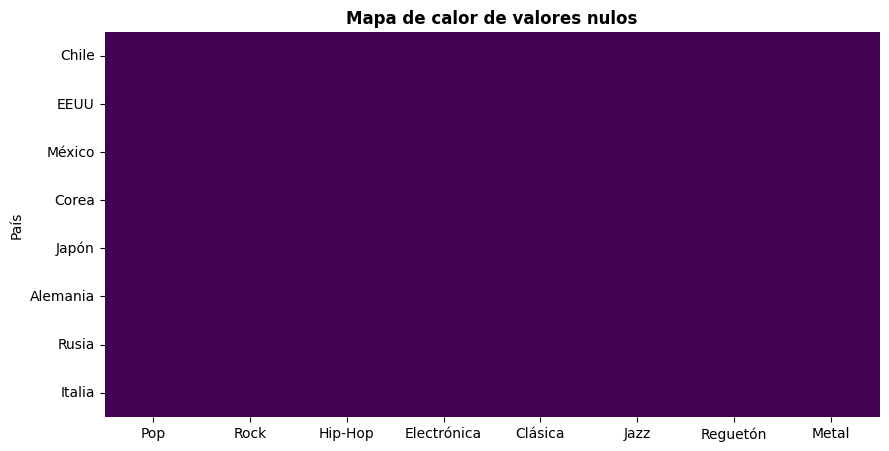

In [216]:
# Exploración inicial

tabla(df.head(5),title="Primeras 5 filas")

print(f"Información inicial del data set:")

df.columns= df.columns.str.replace(" ", "") # Cambio de nombres de columnas
tabla(df.info())

print("\n Dimensiones del DataFrame:", df.shape)

# Deteccion de duplicados
print(f'Número de duplicados: {df.duplicated().sum()}')

# Detección de valores nulos
tabla(df.isnull().sum(), title=" Valores nulos:")

tabla(df.describe(),title=" Estadísticas descriptivas:")

# Visualización nulos

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=True,
            color=sns.color_palette("viridis")[3])
plt.title("Mapa de calor de valores nulos", fontsize=12, fontweight="bold")
plt.show()

El dataset nos muestra los gustos musicales en 8 países, no se entiende el sistema de medición de gustos.

No se detectan valores nulos, ni duplicados, por ende no hay tratamiento de aquelloa valores.

Procedemos a revisar si existen outliers, y sus distribuciones


 DataFrame numérica
--------------------
╒════════╤═══════╤════════╤═══════════╤═══════════════╤═══════════╤════════╤════════════╤═════════╕
│ País   │   Pop │   Rock │   Hip-Hop │   Electrónica │   Clásica │   Jazz │   Reguetón │   Metal │
╞════════╪═══════╪════════╪═══════════╪═══════════════╪═══════════╪════════╪════════════╪═════════╡
│ Chile  │    71 │     22 │        79 │            61 │        70 │     58 │         79 │      69 │
├────────┼───────┼────────┼───────────┼───────────────┼───────────┼────────┼────────────┼─────────┤
│ EEUU   │    34 │     41 │        40 │            79 │        74 │     37 │         90 │      23 │
├────────┼───────┼────────┼───────────┼───────────────┼───────────┼────────┼────────────┼─────────┤
│ México │    91 │     72 │        52 │            99 │        83 │     23 │         63 │      21 │
├────────┼───────┼────────┼───────────┼───────────────┼───────────┼────────┼────────────┼─────────┤
│ Corea  │    80 │     21 │        95 │            34 │   

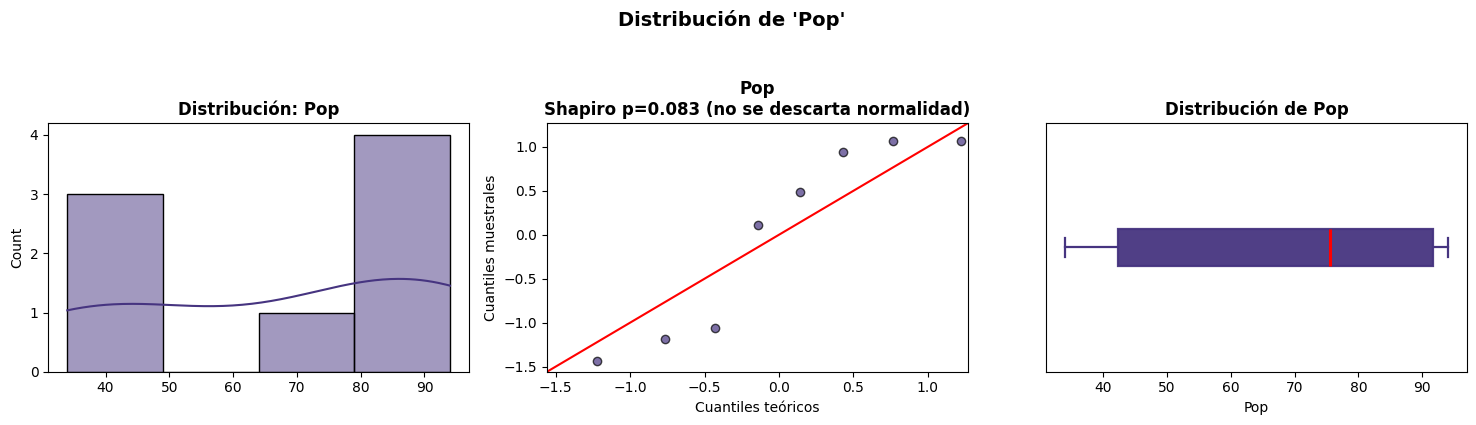

Outliers detectados en Rock: 0 (0.00%)
Límites:
  Q1: 21.75
  Q3: 60.75
  IQR: 39.00
  limite_inferior: -36.75
  limite_superior: 119.25
Tamaño sin outliers: (8, 8)


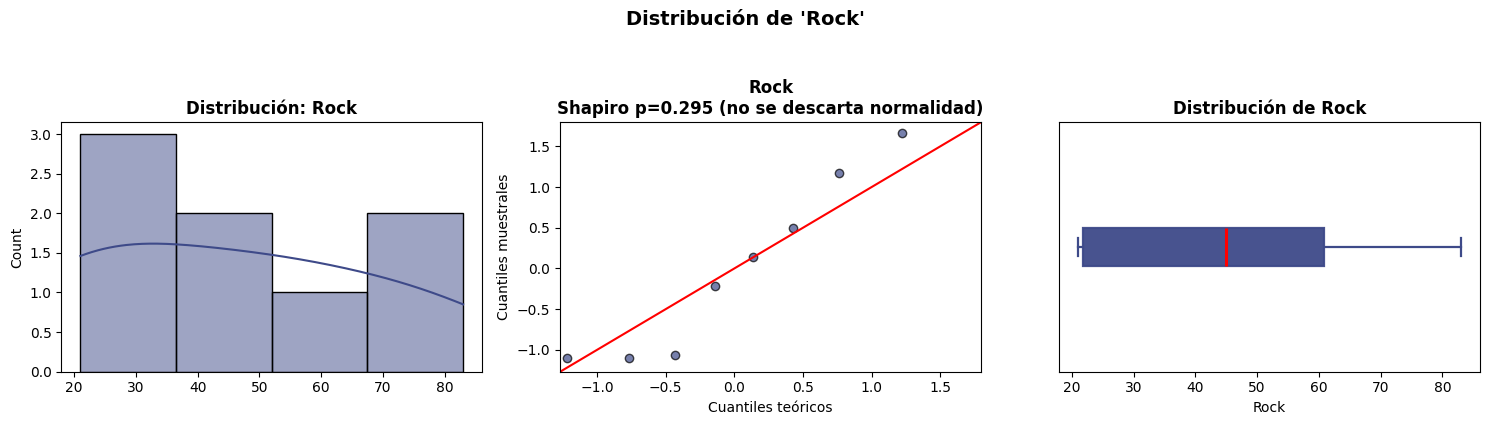

Outliers detectados en Hip-Hop: 0 (0.00%)
Límites:
  Q1: 49.25
  Q3: 78.25
  IQR: 29.00
  limite_inferior: 5.75
  limite_superior: 121.75
Tamaño sin outliers: (8, 8)


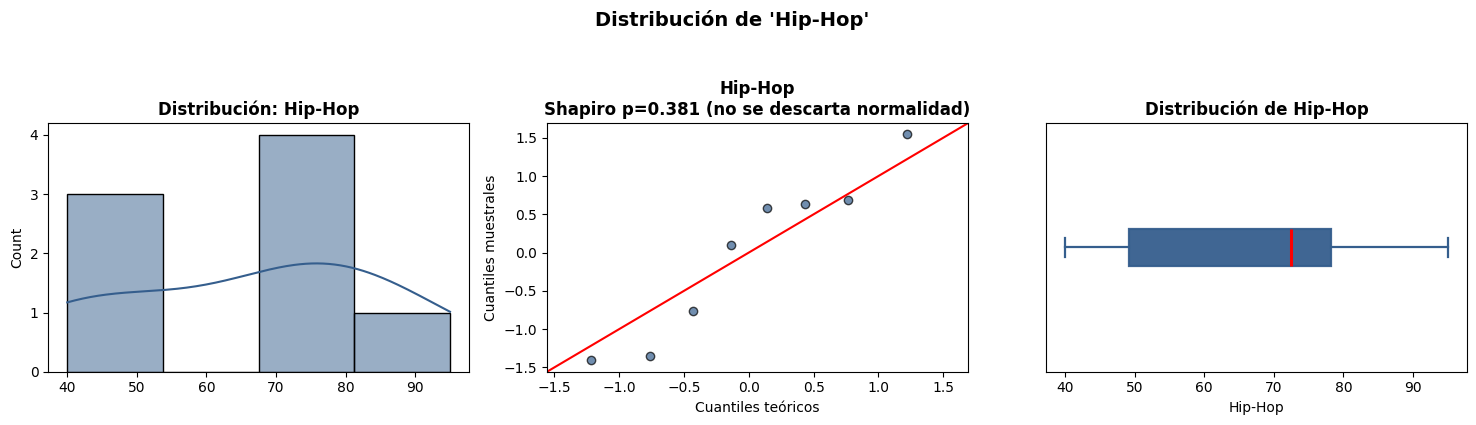

Outliers detectados en Electrónica: 1 (12.50%)
Límites:
  Q1: 64.75
  Q3: 81.00
  IQR: 16.25
  limite_inferior: 40.38
  limite_superior: 105.38
Tamaño sin outliers: (7, 8)


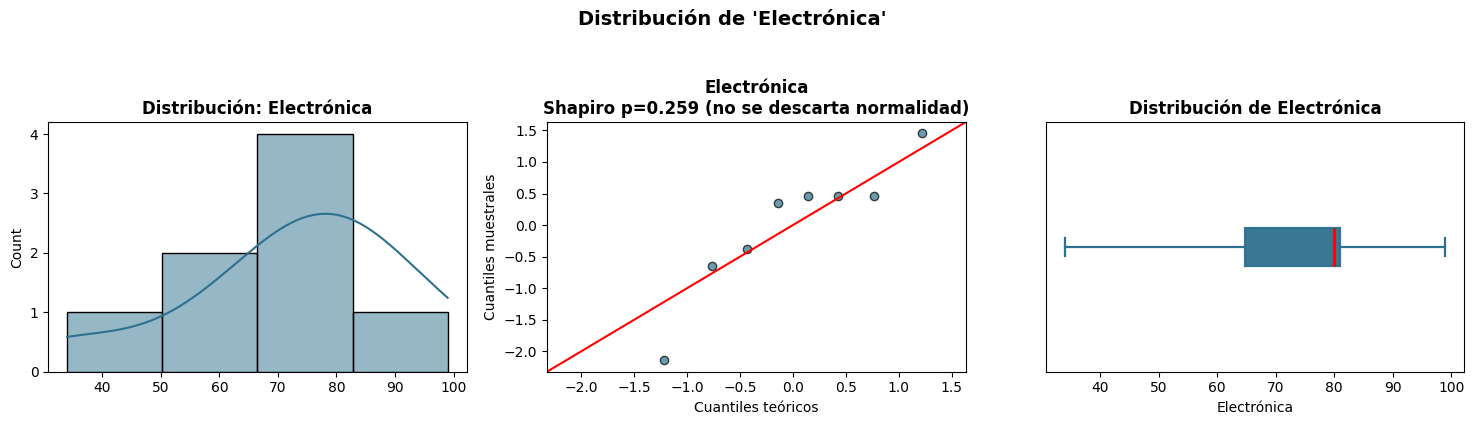

Outliers detectados en Clásica: 0 (0.00%)
Límites:
  Q1: 36.50
  Q3: 76.25
  IQR: 39.75
  limite_inferior: -23.12
  limite_superior: 135.88
Tamaño sin outliers: (8, 8)


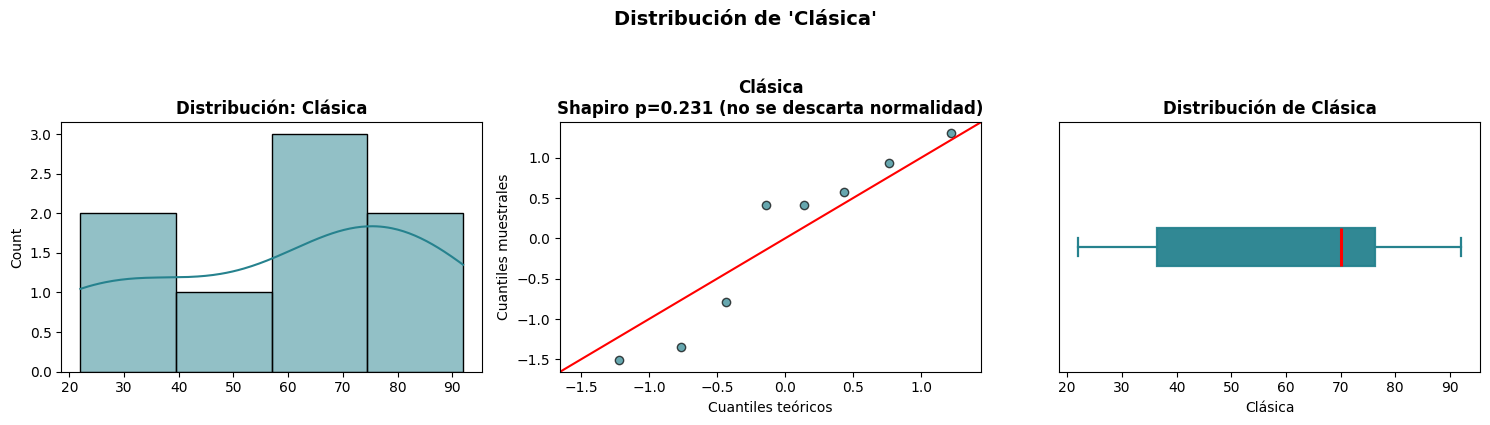

Outliers detectados en Jazz: 0 (0.00%)
Límites:
  Q1: 26.75
  Q3: 61.50
  IQR: 34.75
  limite_inferior: -25.38
  limite_superior: 113.62
Tamaño sin outliers: (8, 8)


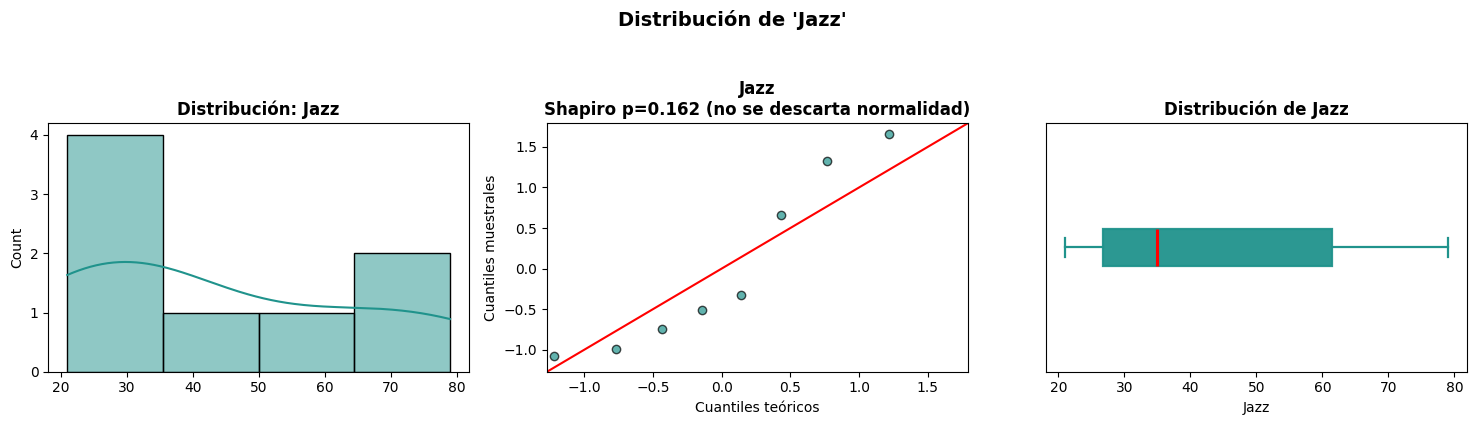

Outliers detectados en Reguetón: 0 (0.00%)
Límites:
  Q1: 54.75
  Q3: 81.75
  IQR: 27.00
  limite_inferior: 14.25
  limite_superior: 122.25
Tamaño sin outliers: (8, 8)


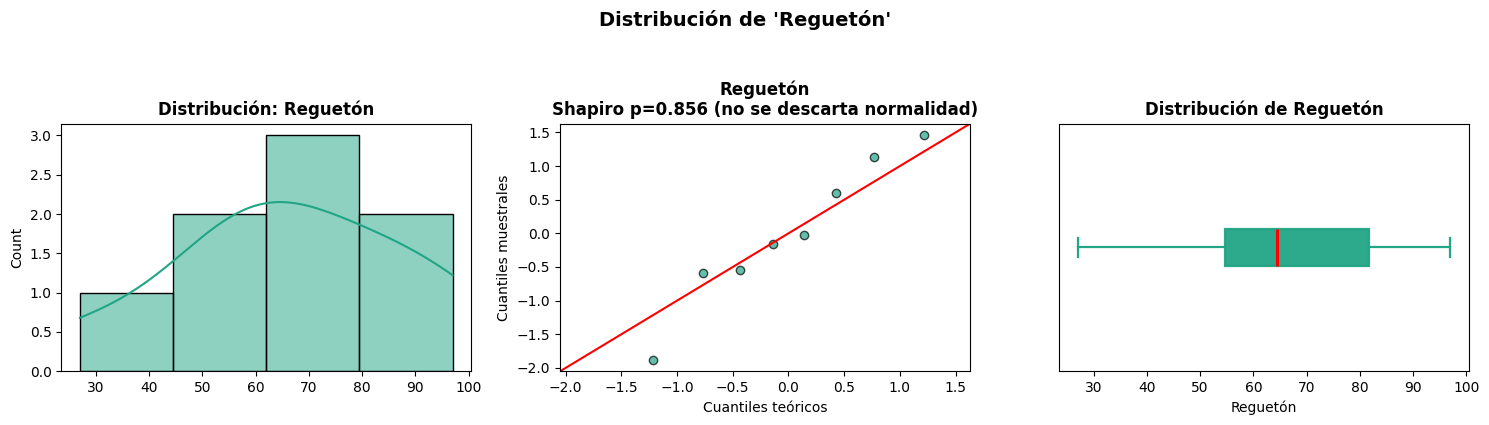

Outliers detectados en Metal: 0 (0.00%)
Límites:
  Q1: 23.00
  Q3: 73.00
  IQR: 50.00
  limite_inferior: -52.00
  limite_superior: 148.00
Tamaño sin outliers: (8, 8)


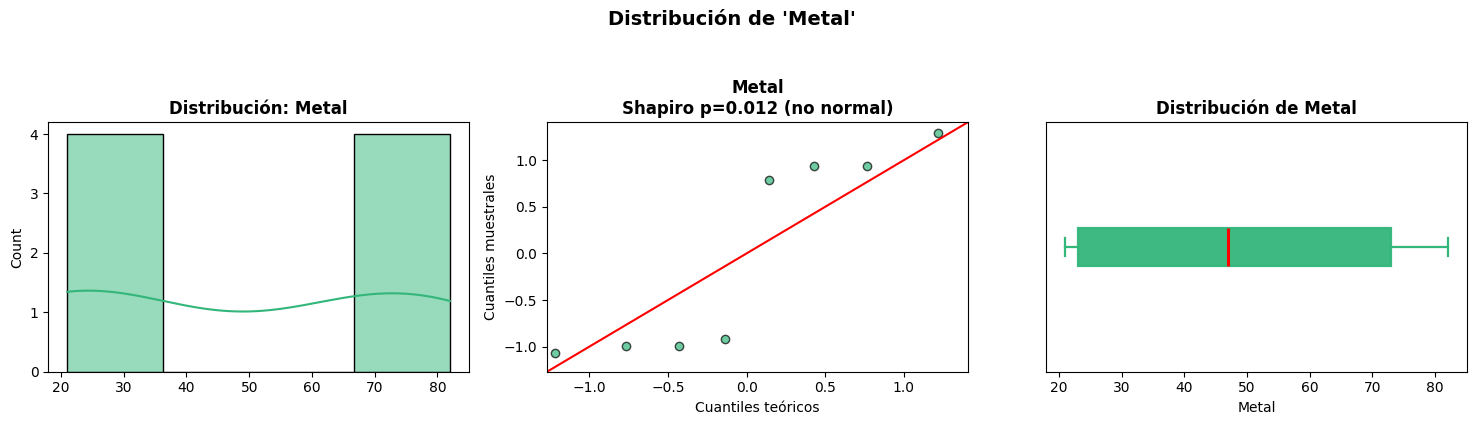

In [217]:
# Detección de valores atípicos

columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns
df_numerica=df[columnas_numericas]
tabla(df_numerica.head(5),title="DataFrame numérica")
n=0
for col in columnas_numericas:
    detectar_outliers_iqr(df,col,graficar=False,n=n)
    triple_plot(df, col, n=n, bins='sturges', alpha=0.05, whis=1.95, showfliers=False, log=False)
    n+=1

In [218]:
# función kmeans

def run_kmeans_pipeline(
    df,
    k=3,
    scale=True,
    scaler="standard",      # "standard" | "minmax"
    palette=None,           # usa tu VIRIDIS si la pasas; si no, usa "viridis"
    random_state=42,
    show_pairplot=True,
    max_pairplot_vars=6     # para no saturar el pairplot si hay muchas columnas
):
    """
    Ejecuta K-Means con opciones de escalado, arma PCA(2D) manteniendo index,
    crea tabla de conteos por cluster y dibuja pairplot con paleta Viridis.
    
    Retorna dict con:
      - model (KMeans), pca (PCA), scaler_obj (o None)
      - df_with_clusters (df original + 'cluster')
      - df_pca (PC1, PC2, cluster)
      - cluster_counts (tabla cantidad y %)
      - centroids_scaled (si scale=True) y centroids_original (en unidades originales si aplica)
      - pca_fig, pca_ax (handlers de la figura del PCA scatter)
    """
    # 0) Preparación de datos
    df_num = df.select_dtypes(include=[np.number]).copy()
    if df_num.empty:
        raise ValueError("El DataFrame no contiene columnas numéricas.")
    
    # Limpieza básica para seguridad
    df_num = df_num.replace([np.inf, -np.inf], np.nan).dropna()
    if df_num.shape[0] < k:
        raise ValueError(f"Hay {df_num.shape[0]} filas numéricas válidas, menor que k={k}.")

    # 1) Escalado opcional
    X = df_num.values
    scaler_obj = None
    if scale:
        if scaler == "standard":
            scaler_obj = StandardScaler()
        elif scaler == "minmax":
            scaler_obj = MinMaxScaler()
        else:
            raise ValueError("scaler debe ser 'standard' o 'minmax'.")
        X_used = scaler_obj.fit_transform(X)
    else:
        X_used = X
    df_used = pd.DataFrame(X_used, columns=df_num.columns, index=df_num.index)
    # 2) KMeans
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=random_state)
    labels_arr = kmeans.fit_predict(df_used.values)  # valores numéricos
    labels = pd.Series(labels_arr, index=df_used.index, name="cluster")
    
    # Centroides (en el espacio usado por el ajuste)
    cent_scaled_df = pd.DataFrame(kmeans.cluster_centers_, columns=df_num.columns)
    # Centroides en unidades originales (si escalaste y hay inverse_transform)
    if scale and hasattr(scaler_obj, "inverse_transform"):
        cent_orig_df = pd.DataFrame(
            scaler_obj.inverse_transform(kmeans.cluster_centers_),
            columns=df_used.columns
        )
    else:
        cent_orig_df = cent_scaled_df.copy()

    # df con etiquetas (alineado al índice de df original donde hay datos numéricos válidos)
    df_with_clusters = df.copy()
    df_with_clusters.loc[df_used.index, "cluster"] = labels

    # 3) PCA(2D) manteniendo index
    pca = PCA(n_components=2, random_state=random_state)
    pca_2d = pca.fit_transform(df_used)
    df_pca = pd.DataFrame(pca_2d, columns=["PC1", "PC2"], index=df_used.index)
    df_pca["cluster"] = labels

    # 4) Tablas cluster
    cluster_counts = (
        labels.value_counts().sort_index().to_frame(name="Cantidad de datos")
    )
    cluster_counts["Proporción"] = (cluster_counts["Cantidad de datos"]
                                    / cluster_counts["Cantidad de datos"].sum() * 100).round(2)

    # 5) Visual: pairplot con Viridis
    if palette is None:
        palette = "viridis"
    # Gráfico
    if show_pairplot:
        hue_levels = sorted(df_with_clusters["cluster"].dropna().unique())

        sns.pairplot(df_with_clusters[df_num.columns.tolist()[:max_pairplot_vars] + ["cluster"]],
                     hue="cluster",
                     hue_order=hue_levels,
                     palette=palette,
                     diag_kind="auto",   
                     plot_kws={"edgecolor": "k", "linewidth": 0.5}
                )
        plt.suptitle("Visualización por Clusters", y=1.02, fontsize=14, weight='bold')
        plt.show()

    # 6) Scatter PCA con centroide
    # Paleta para scatter PCA: mapeo de cluster → color (lista exacta)
    hue_levels_pca = sorted(df_pca["cluster"].unique())
    pca_fig, pca_ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=df_pca,
        x="PC1", y="PC2",
        hue="cluster",
        hue_order=hue_levels_pca,
        palette=palette,
        edgecolor="k",linewidth=0.5,
        alpha=0.7,
        s=60,
        ax=pca_ax
    )
    for idx, (x, y) in df_pca[["PC1", "PC2"]].iterrows():
        pca_ax.annotate(str(idx), (x + 0.04, y + 0.04), fontsize=9)

    pca_ax.set_xlabel("PC1")
    pca_ax.set_ylabel("PC2")
    pca_ax.set_title("Clusters proyectados en 2D (PCA)", fontsize=14, weight="bold")

    # Proyectar centroides al espacio PCA sin warnings (usar DataFrame con mismas columnas)
    centers_pca = pca.transform(pd.DataFrame(cent_scaled_df, columns=df_used.columns))


    pca_ax.scatter(
        centers_pca[:, 0], centers_pca[:, 1],
        c='red', s=200, marker='X', edgecolors='k', linewidths=2,
        label="Centroides"
    )
    pca_ax.legend(title="Clusters + Centroides")
    pca_fig.tight_layout()
    plt.show()

    # 7) Impresiones útiles
    #print("Centroides (espacio del modelo – escalado):")
    #display(cent_scaled_df.style.format("{:.4f}"))
#
    #if scale:
    #    print("Centroides en unidades originales:")
    #    display(cent_orig_df.style.format("{:.4f}"))
    print("Cantidad de datos por cluster")
    display(cluster_counts)

    return {
        "model": kmeans,
        "pca": pca,
        "scaler_obj": scaler_obj,
        "labels": labels,                         # Series con índices originales
        "df_with_clusters": df_with_clusters,     # df original + cluster
        "df_pca": df_pca,                         # PC1, PC2, cluster
        "cluster_counts": cluster_counts,         # tabla cantidad y %
        "centroids_scaled": cent_scaled_df,       # centroides en espacio del modelo
        "centroids_original": cent_orig_df,       # centroides en unidades originales (si scale=True)
        "pca_fig": pca_fig, "pca_ax": pca_ax,  
        "X_scales":X_used
    }

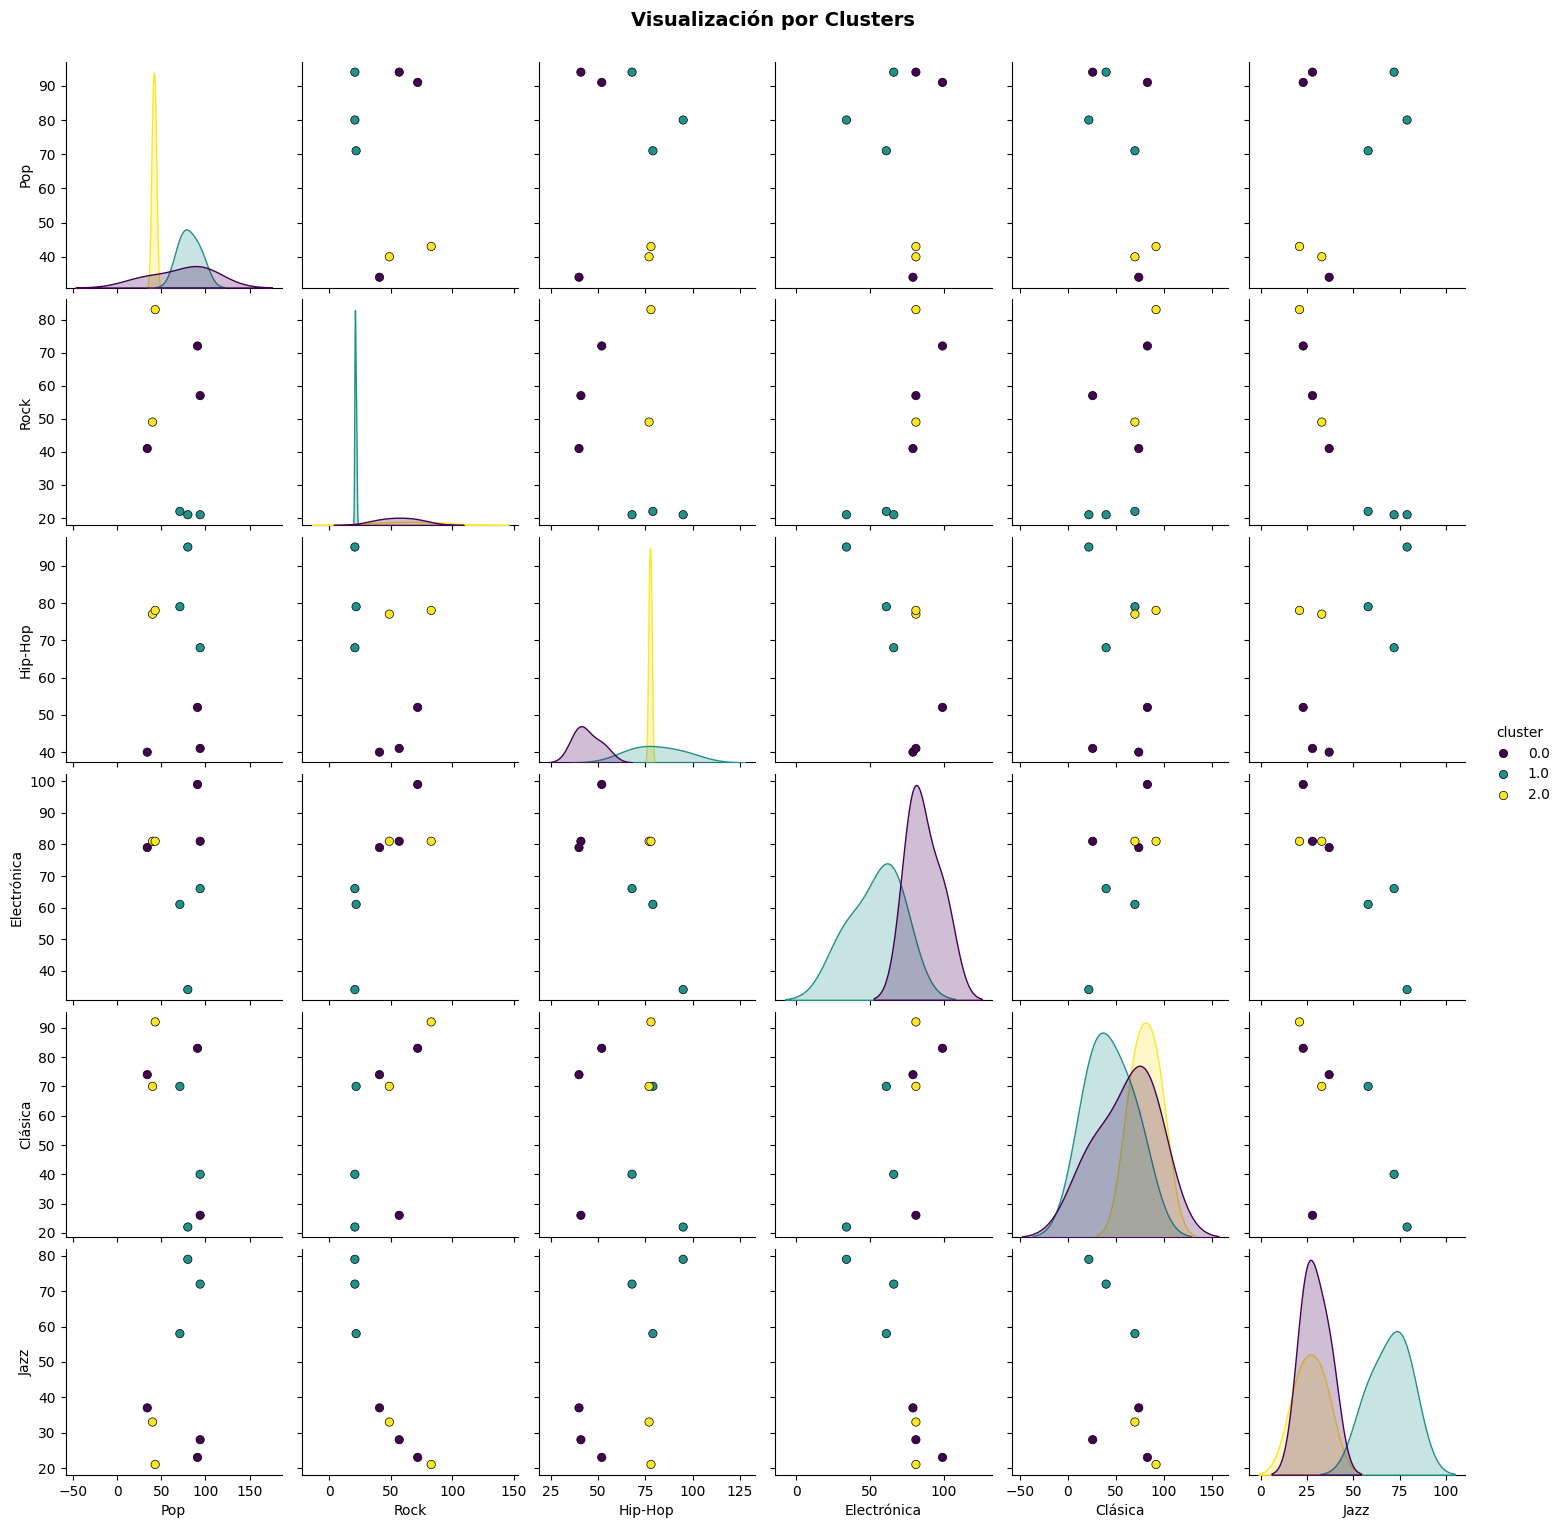

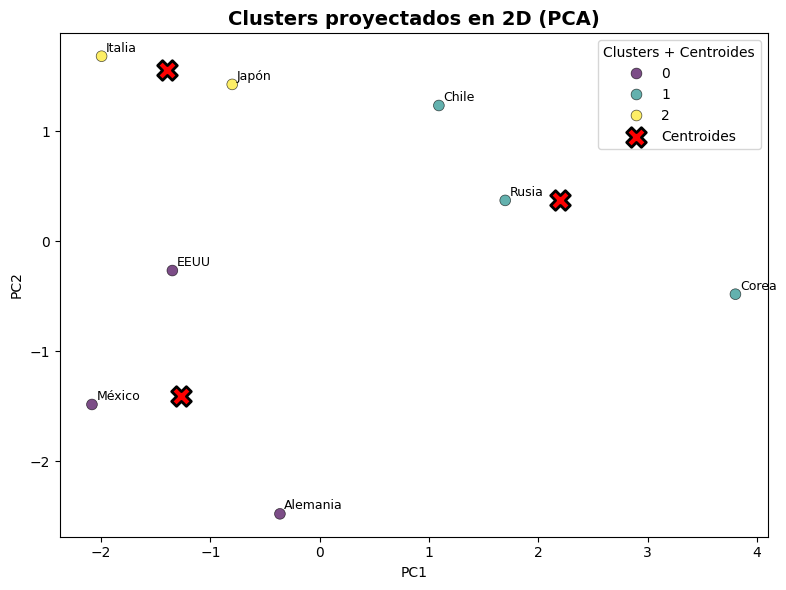

Cantidad de datos por cluster


,Cantidad de datos,Proporción
cluster,,
0,3,37.5
1,3,37.5
2,2,25.0


╒════════╤═══════╤════════╤═══════════╤═══════════════╤═══════════╤════════╤════════════╤═════════╤═══════════╕
│ País   │   Pop │   Rock │   Hip-Hop │   Electrónica │   Clásica │   Jazz │   Reguetón │   Metal │   cluster │
╞════════╪═══════╪════════╪═══════════╪═══════════════╪═══════════╪════════╪════════════╪═════════╪═══════════╡
│ Chile  │    71 │     22 │        79 │            61 │        70 │     58 │         79 │      69 │         1 │
├────────┼───────┼────────┼───────────┼───────────────┼───────────┼────────┼────────────┼─────────┼───────────┤
│ EEUU   │    34 │     41 │        40 │            79 │        74 │     37 │         90 │      23 │         0 │
├────────┼───────┼────────┼───────────┼───────────────┼───────────┼────────┼────────────┼─────────┼───────────┤
│ México │    91 │     72 │        52 │            99 │        83 │     23 │         63 │      21 │         0 │
├────────┼───────┼────────┼───────────┼───────────────┼───────────┼────────┼────────────┼─────────┼─────

In [219]:
# Kmeans (k=3)
res = run_kmeans_pipeline(
    df=df, 
    k=3, 
    scale=True, 
    scaler="standard",  
    random_state=42, 
    show_pairplot=True,
)

tabla(res['df_with_clusters'].head())


In [220]:
# función gráfico codo y selección 

def elbow_auto_plot(X, k_min=2, k_cap=10, scale=True, scaler="standard", 
                    method="absolute", palette=None, seed=42, show=True):
    """
    Método del codo automatizado para KMeans.
    
    Parámetros
    ----------
    X : array o DataFrame
        Datos de entrada.
    k_min : int
        Número mínimo de clusters a probar (default=2).
    k_cap : int
        Máximo k a evaluar (se ajusta a n_samples-1 si es más grande).
    scale : bool
        Si True, escala los datos antes de aplicar KMeans.
    scaler : str
        "standard" (StandardScaler) o "minmax" (MinMaxScaler).
    method : str
        Método para elegir el codo: "absolute" o "relative".
    palette : lista o None
        Paleta de colores (ej. VIRIDIS).
    seed : int
        Semilla aleatoria para reproducibilidad.
    show : bool
        Si True, muestra el gráfico.
    """
    X_arr = np.asarray(X)
    n_samples = X_arr.shape[0]

    # Escalado opcional
    if scale:
        if scaler == "standard":
            X_arr = StandardScaler().fit_transform(X_arr)
        elif scaler == "minmax":
            X_arr = MinMaxScaler().fit_transform(X_arr)

    # Rango de k
    k_max = max(k_min, min(k_cap, n_samples - 1))
    k_values = list(range(k_min, k_max + 1))

    # Inercias
    inertias = []
    for k in k_values:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=seed)
        km.fit(X_arr)
        inertias.append(km.inertia_)

    # Método del codo
    if len(inertias) >= 2:
        diffs = np.diff(inertias) * -1           # mejoras positivas
        rel_diffs = diffs / np.array(inertias[:-1])
        # Elegir el codo según método
        if method == "relative":
            elbow_idx = int(np.argmax(rel_diffs))
        else:  # "absolute" por defecto
            elbow_idx = int(np.argmax(diffs))
        elbow_k = k_values[elbow_idx + 1]
    else:
        diffs = np.array([])
        rel_diffs = np.array([])
        elbow_k = k_values[0]


    # Crear DataFrame
    df_out = pd.DataFrame({
        "k": k_values,
        "inertia": inertias,
        "delta_inertia": [np.nan] + diffs.tolist(),
        "delta_relative": [np.nan] + rel_diffs.tolist(),
        "method": method,
        "scaled": scale,
        "scaler": scaler
    }).set_index("k")

    df_out["is_elbow"] = df_out.index == elbow_k

    # Paleta 
    line_color = "black"
    line_colordos= "black"
    if palette is not None:
        try:
            line_color = palette[5]   # toma un color intermedio si existe
            line_colordos= palette[0]
        except Exception:
            line_color = "black"
            line_colordos= "black"
    # Gráfico
    if show:
        vir = plt.cm.viridis
        colors = vir(np.linspace(0, 1, len(k_values)))
        colors2 = vir(np.linspace(0, 1, len(k_values)-1)) if len(k_values) > 1 else None

        fig, ax1 = plt.subplots(figsize=(8,6))
        # Inercia
        ax1.plot(k_values, inertias, marker="o", color=line_color, label="Inercia total")
        ax1.set_xlabel("Número de clusters (k)")
        ax1.set_ylabel("Inercia (SSE)", color="black")
        ax1.tick_params(axis="y", labelcolor="black")
        ax1.grid(True, linestyle="--", alpha=0.4)
        ax1.axvline(elbow_k, linestyle="--", alpha=0.6, color=line_colordos,
                    label=f"Codo sugerido: k={elbow_k}")

        # Deltas
        ax2 = ax1.twinx()
        if diffs.size:
            ax2.bar(k_values[1:], diffs, color=colors2, alpha=0.25, label="Δ Inercia")
        ax2.set_ylabel("Δ Inercia", color="black")
        ax2.tick_params(axis="y", labelcolor="black")

        # Leyenda
        lines1, labs1 = ax1.get_legend_handles_labels()
        lines2, labs2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labs1 + labs2, loc="best")

        plt.title(f"Método del codo ({method}, scale={scale}, scaler={scaler})", fontsize=14, weight="bold")
        plt.tight_layout()
        plt.show()

    return df_out, elbow_k


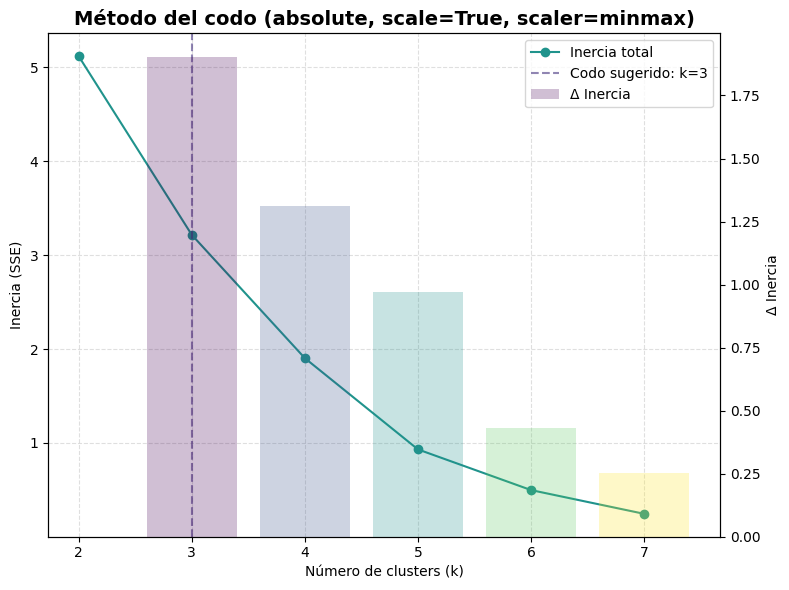


 Resultado método absoluto
---------------------------
╒═════╤═══════════╤═════════════════╤══════════════════╤══════════╤══════════╤══════════╤════════════╕
│   k │   inertia │   delta_inertia │   delta_relative │ method   │ scaled   │ scaler   │ is_elbow   │
╞═════╪═══════════╪═════════════════╪══════════════════╪══════════╪══════════╪══════════╪════════════╡
│   2 │      5.12 │          nan    │           nan    │ absolute │ True     │ minmax   │ False      │
├─────┼───────────┼─────────────────┼──────────────────┼──────────┼──────────┼──────────┼────────────┤
│   3 │      3.22 │            1.9  │             0.37 │ absolute │ True     │ minmax   │ True       │
├─────┼───────────┼─────────────────┼──────────────────┼──────────┼──────────┼──────────┼────────────┤
│   4 │      1.9  │            1.31 │             0.41 │ absolute │ True     │ minmax   │ False      │
├─────┼───────────┼─────────────────┼──────────────────┼──────────┼──────────┼──────────┼────────────┤
│   5 │      0.93

In [221]:
# método absoluto 
 
no_scale, codo= elbow_auto_plot(
    X=df,
    scale=True,           # no escalamos
    scaler="minmax",     # se ignora porque scale=False
    method="absolute",     # mayor caída absoluta de inercia
    k_cap=10,
    palette=VIRIDIS,
    seed=42,
    show=True
)

tabla(no_scale,title="Resultado método absoluto")

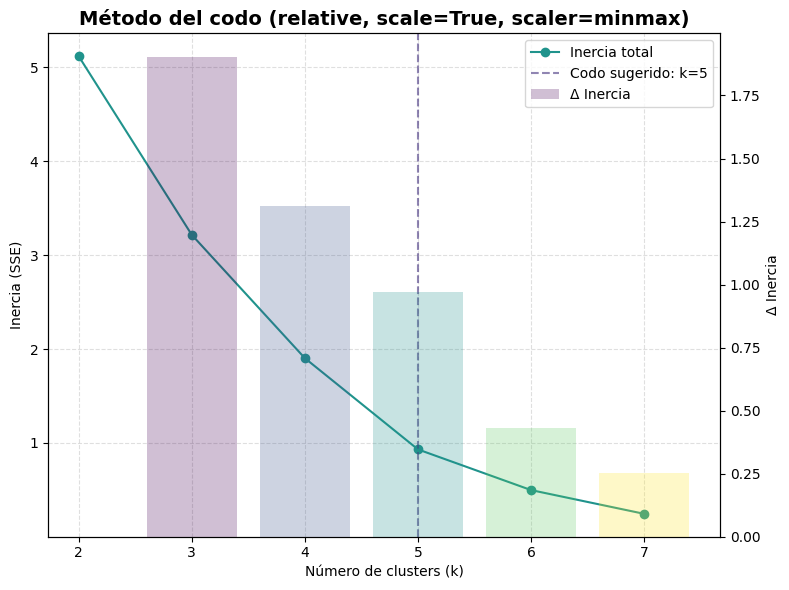


 Resultado método relativo 
----------------------------
╒═════╤═══════════╤═════════════════╤══════════════════╤══════════╤══════════╤══════════╤════════════╕
│   k │   inertia │   delta_inertia │   delta_relative │ method   │ scaled   │ scaler   │ is_elbow   │
╞═════╪═══════════╪═════════════════╪══════════════════╪══════════╪══════════╪══════════╪════════════╡
│   2 │      5.12 │          nan    │           nan    │ relative │ True     │ minmax   │ False      │
├─────┼───────────┼─────────────────┼──────────────────┼──────────┼──────────┼──────────┼────────────┤
│   3 │      3.22 │            1.9  │             0.37 │ relative │ True     │ minmax   │ False      │
├─────┼───────────┼─────────────────┼──────────────────┼──────────┼──────────┼──────────┼────────────┤
│   4 │      1.9  │            1.31 │             0.41 │ relative │ True     │ minmax   │ False      │
├─────┼───────────┼─────────────────┼──────────────────┼──────────┼──────────┼──────────┼────────────┤
│   5 │      0.

In [222]:
# metodo relativo 
si_scale, codo= elbow_auto_plot(
    X=df,
    scale=True,           # escalamos min max
    scaler="minmax",     # se ignora porque scale=False
    method="relative",     # mayor caída absoluta de inercia
    k_cap=10,
    palette=VIRIDIS,
    seed=42,
    show=True
)
tabla(si_scale,title="Resultado método relativo ")

In [223]:
# Funcion de la silueta

def silhouette_auto_plot(X, k_min=2, k_cap=10, scale=True, scaler="standard",
                         seed=42, palette=None, show=True):
    """
    Evalúa Silhouette vs k para KMeans y devuelve (df_resultados, best_k).

    Parámetros
    ------
    X : array-like o DataFrame (solo numérico)
    k_min : int, mínimo k a evaluar (>=2)
    k_cap : int, máximo k a intentar (cap superior; se ajusta a n_samples-1)
    scale : bool, si True escala X antes (recomendado para KMeans)
    scaler : {"standard","minmax"}
    seed : int, semilla de reproducibilidad
    palette : lista o None, Paleta de colores (ej. VIRIDIS).
    show : bool, si True grafica Silhouette vs k

    Retorna
    ------
    df_out : DataFrame indexado por k con columnas:
             ["silhouette", "n_clusters", "scaled", "scaler", "is_best"]
    best_k : int, k con mayor coeficiente de silueta
    """
    # saneamiento básico
    X_arr = np.asarray(X, dtype=float)
    # quita filas con NaN/inf si existieran
    mask = np.isfinite(X_arr).all(axis=1)
    X_arr = X_arr[mask]
    n_samples = X_arr.shape[0]

    if n_samples < 3:
        raise ValueError("Se requieren ≥3 muestras para calcular silueta.")

    # escalado opcional
    if scale:
        if scaler == "standard":
            X_arr = StandardScaler().fit_transform(X_arr)
        elif scaler == "minmax":
            X_arr = MinMaxScaler().fit_transform(X_arr)

    # rango de k válido
    k_max = max(k_min, min(k_cap, n_samples - 1))
    if k_max < 2:
        raise ValueError("Con tan pocas muestras no es posible evaluar k≥2.")
    k_values = list(range(k_min, k_max + 1))

    # cálculo de silueta
    sil_scores = []
    for k in k_values:
        km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=seed)
        labels = km.fit_predict(X_arr)
        # silueta válida solo si hay >1 cluster y ningún cluster vacío
        if len(np.unique(labels)) > 1:
            s = silhouette_score(X_arr, labels)
        else:
            s = np.nan
        sil_scores.append(s)

    # mejor k (ignorando NaN)
    if np.all(np.isnan(sil_scores)):
        best_k = k_values[0]
    else:
        best_idx = int(np.nanargmax(sil_scores))
        best_k = k_values[best_idx]

    # DataFrame de salida
    df_out = pd.DataFrame({
        "k": k_values,
        "silhouette": sil_scores,
        "n_clusters": k_values,
        "scaled": scale,
        "scaler": scaler
    }).set_index("k")
    df_out["is_best"] = df_out.index == best_k

    # Paleta 
    line_color = "black"
    if palette is not None:
        try:
            line_color = palette[6]   
        except Exception:
            line_color = "black"
    # gráfico opcional
    if show:
        colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))
        plt.figure(figsize=(8,5))
        plt.plot(k_values, sil_scores, marker="o", linewidth=1.5, color=line_color)
        
        # marca best_k
        best_s = df_out.loc[best_k, "silhouette"]
        if np.isfinite(best_s):
            plt.scatter(best_k, best_s, s=220, marker="X",
                        edgecolors="k", linewidths=2, color="red",
                        label=f"Mejor k: {best_k} (s={best_s:.3f})")
        plt.title(f"Silueta vs k (scale={scale}, scaler={scaler})",
                  fontsize=14, weight="bold")
        plt.xlabel("Número de clusters (k)")
        plt.ylabel("Silueta (−1 a 1)")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return df_out, best_k

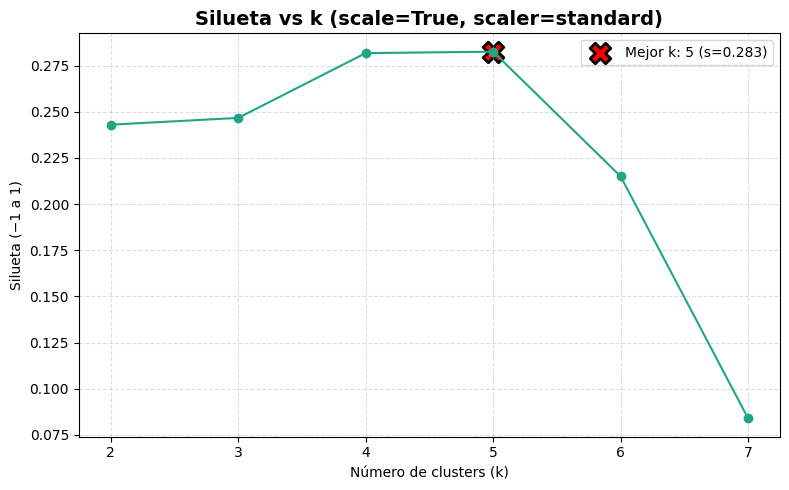

Mejor k por silueta: 5
╒═════╤══════════════╤══════════════╤══════════╤══════════╤═══════════╕
│   k │   silhouette │   n_clusters │ scaled   │ scaler   │ is_best   │
╞═════╪══════════════╪══════════════╪══════════╪══════════╪═══════════╡
│   2 │         0.24 │            2 │ True     │ standard │ False     │
├─────┼──────────────┼──────────────┼──────────┼──────────┼───────────┤
│   3 │         0.25 │            3 │ True     │ standard │ False     │
├─────┼──────────────┼──────────────┼──────────┼──────────┼───────────┤
│   4 │         0.28 │            4 │ True     │ standard │ False     │
├─────┼──────────────┼──────────────┼──────────┼──────────┼───────────┤
│   5 │         0.28 │            5 │ True     │ standard │ True      │
├─────┼──────────────┼──────────────┼──────────┼──────────┼───────────┤
│   6 │         0.21 │            6 │ True     │ standard │ False     │
├─────┼──────────────┼──────────────┼──────────┼──────────┼───────────┤
│   7 │         0.08 │            7 │ Tru

In [224]:
# X_num: tus variables numéricas (DataFrame o array)
df_sil, best_k = silhouette_auto_plot(
    X=df,
    k_min=2,
    k_cap=10,
    scale=True,        # recomendado para KMeans
    scaler="standard", # o "minmax"
    seed=42,
    palette=VIRIDIS,
    show=True
)

print("Mejor k por silueta:", best_k)
tabla(df_sil)

Según el método de la silueta, deberíamos trabajar con 5 clúteres. por ende, se aplican 5 clústeres.

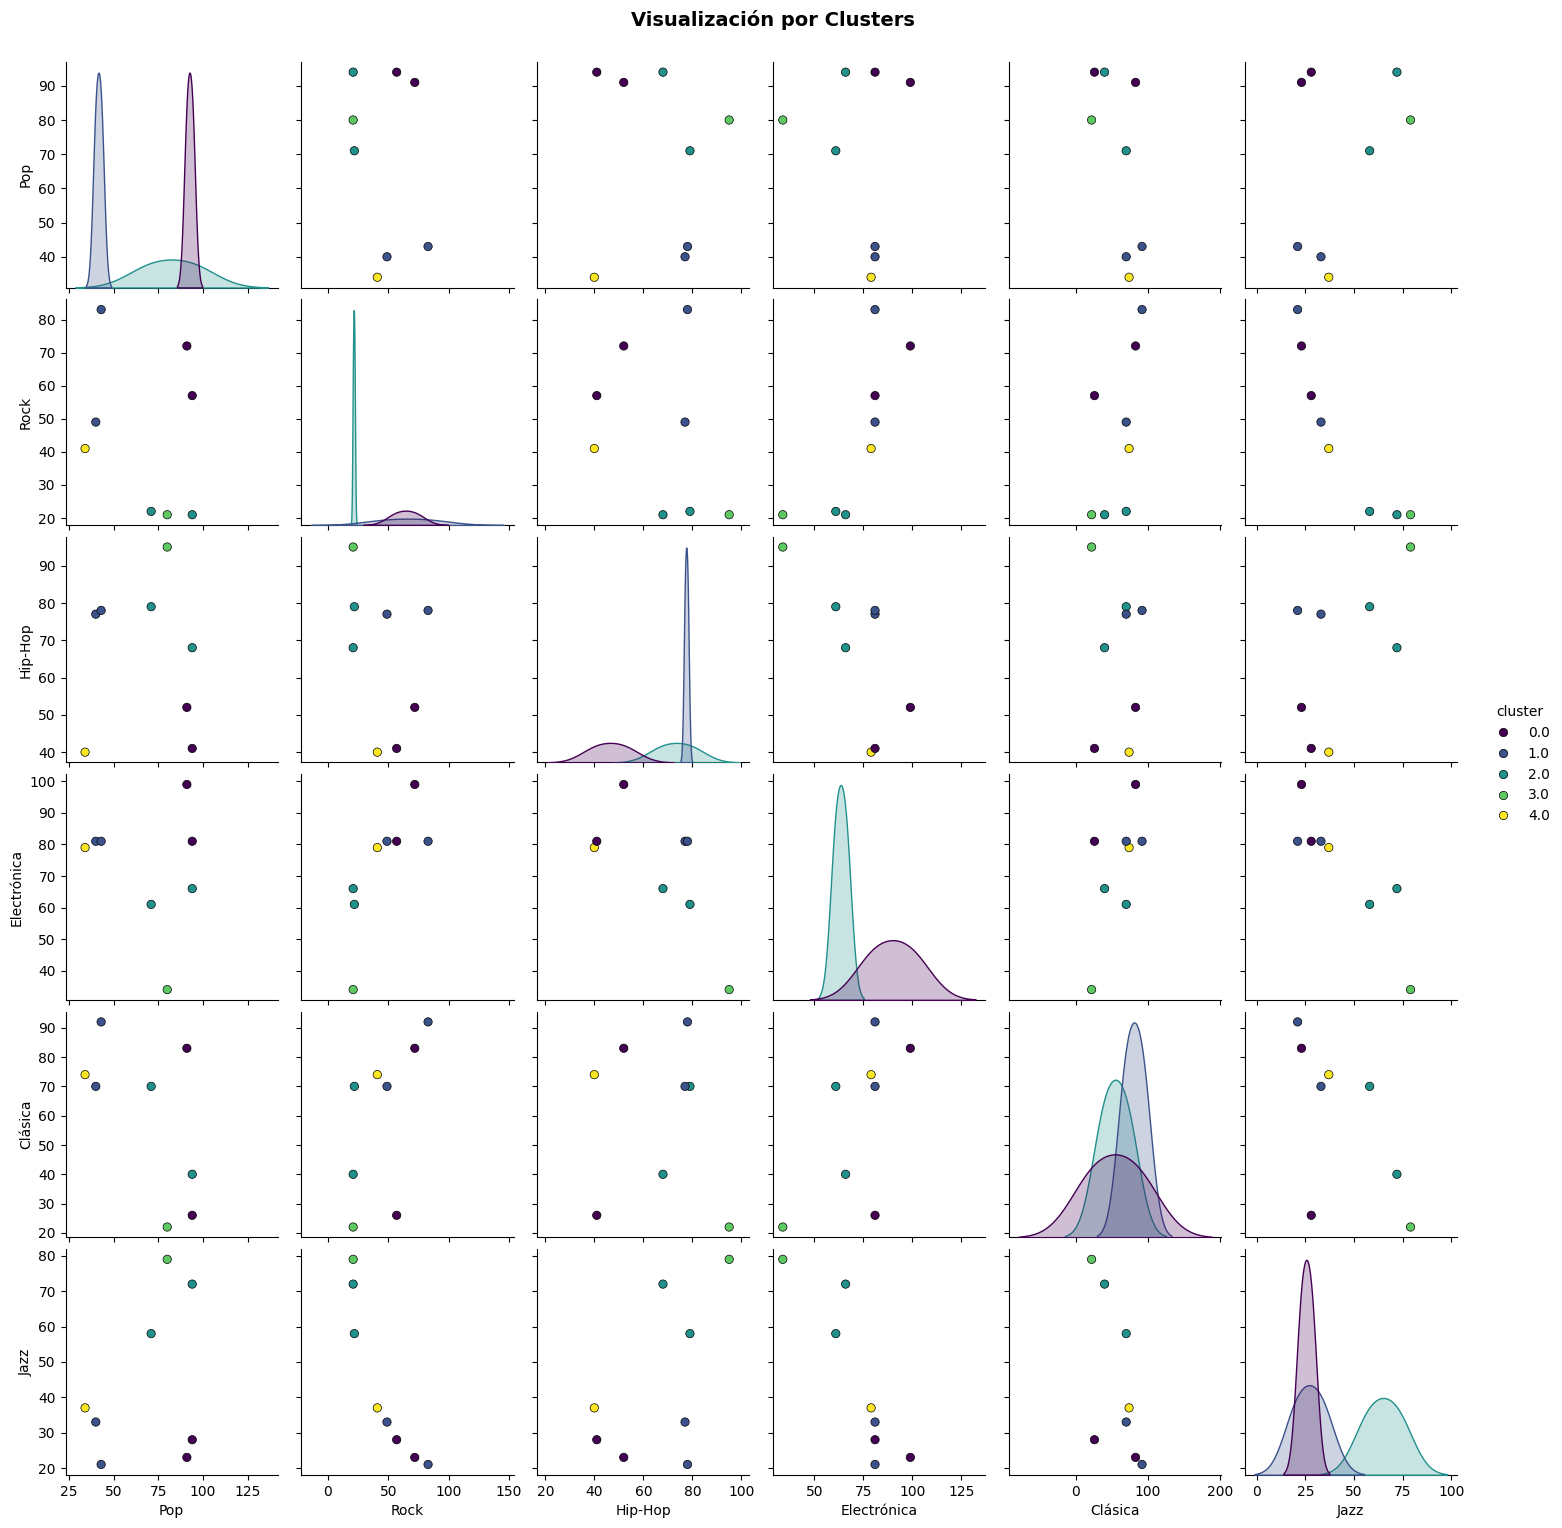

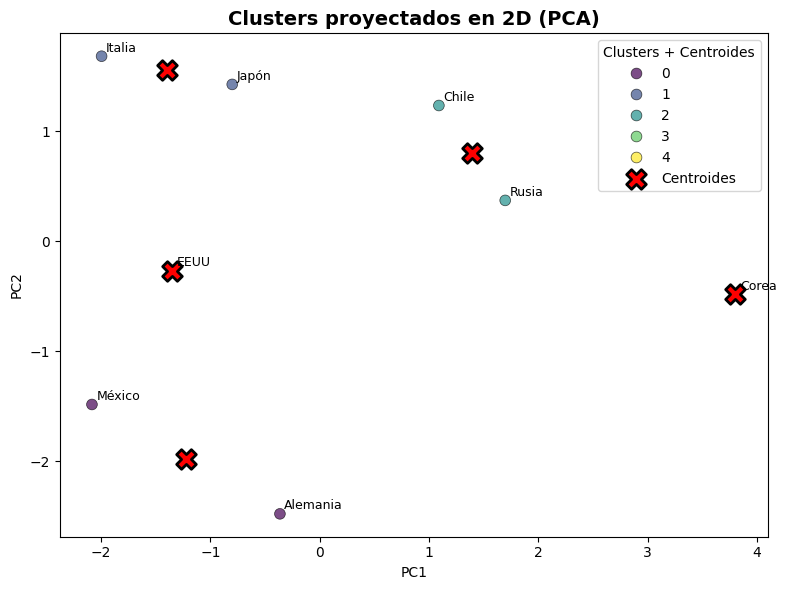

Cantidad de datos por cluster


,Cantidad de datos,Proporción
cluster,,
0,2,25.0
1,2,25.0
2,2,25.0
3,1,12.5
4,1,12.5


╒════════╤═══════╤════════╤═══════════╤═══════════════╤═══════════╤════════╤════════════╤═════════╤═══════════╕
│ País   │   Pop │   Rock │   Hip-Hop │   Electrónica │   Clásica │   Jazz │   Reguetón │   Metal │   cluster │
╞════════╪═══════╪════════╪═══════════╪═══════════════╪═══════════╪════════╪════════════╪═════════╪═══════════╡
│ Chile  │    71 │     22 │        79 │            61 │        70 │     58 │         79 │      69 │         2 │
├────────┼───────┼────────┼───────────┼───────────────┼───────────┼────────┼────────────┼─────────┼───────────┤
│ EEUU   │    34 │     41 │        40 │            79 │        74 │     37 │         90 │      23 │         4 │
├────────┼───────┼────────┼───────────┼───────────────┼───────────┼────────┼────────────┼─────────┼───────────┤
│ México │    91 │     72 │        52 │            99 │        83 │     23 │         63 │      21 │         0 │
├────────┼───────┼────────┼───────────┼───────────────┼───────────┼────────┼────────────┼─────────┼─────

In [225]:
# Kmeans (k=5)
res_cinco = run_kmeans_pipeline(
    df=df, 
    k=5, 
    scale=True, 
    scaler="standard",  
    random_state=42, 
    show_pairplot=True
)

tabla(res_cinco['df_with_clusters'].head())


**Clustering jerárquico**  
- Genera un **dendrograma** y determina el número óptimo de clusters.  
- Aplica **clustering jerárquico** y **compara** con K-Means.


In [226]:
# función dendograma

def plot_dendrogram_with_cut(
    df,
    method="ward",                 # 'ward', 'complete', 'average', 'single'
    metric="euclidean",            # 'euclidean', 'cosine', 'cityblock', etc. (no aplica en ward)
    scale=True,                    # escalar o no antes del clustering
    scaler="standard",             # 'standard' | 'minmax'
    cut_height=None,               # distancia a la que cortamos el dendrograma
    max_leaves=None,               # para truncar si hay muchísimas muestras
    leaf_font_size=8,
    figsize=(10, 6),
    title=None
):
    """
    Dibuja un dendrograma jerárquico y, si se pasa cut_height, colorea por clusters 
    bajo ese corte y reporta cuántos clusters se forman.
    
    Retorna:
        Z            -> matriz de linkage
        labels       -> Series (índice original -> id de cluster) si cut_height, si no None
        n_clusters   -> número de clusters si cut_height, si no None
    """
    # 1) Tomar solo columnas numéricas y limpiar
    df_num = df.select_dtypes(include=[np.number]).copy()
    if df_num.empty:
        raise ValueError("El DataFrame no tiene columnas numéricas.")
    df_num = df_num.replace([np.inf, -np.inf], np.nan).dropna()
    if df_num.shape[0] < 2:
        raise ValueError("Se requieren al menos 2 filas para un dendrograma.")

    # 2) Escalado opcional
    X = df_num.values
    if scale:
        if scaler == "standard":
            X = StandardScaler().fit_transform(X)
        elif scaler == "minmax":
            X = MinMaxScaler().fit_transform(X)
        else:
            raise ValueError("scaler debe ser 'standard' o 'minmax'.")

    # 3) Linkage (¡ojo con 'ward'!)
    # - 'ward' requiere distancia euclídea y datos crudos (NO matriz de distancias).
    # - Para otros métodos puedes pasar la matriz de distancias condensada.
    if method == "ward":
        if metric != "euclidean":
            raise ValueError("Con method='ward' la métrica debe ser 'euclidean'.")
        Z = linkage(X, method="ward")
    else:
        D = pdist(X, metric=metric)
        Z = linkage(D, method=method)

    # 4) Dendrograma
    plt.figure(figsize=figsize)
    # Si hay demasiadas hojas, se puede truncar para legibilidad
    dend_kwargs = {
        "labels": df_num.index.astype(str).tolist(),
        "leaf_rotation": 90,
        "leaf_font_size": leaf_font_size,
        }
    # Si definimos cut_height, lo usamos para colorear por clusters
    if cut_height is not None:
        dend_kwargs["color_threshold"] = cut_height

    # Truncado opcional
    if max_leaves is not None and max_leaves > 0:
        dend_kwargs.update({"truncate_mode": "lastp", "p": int(max_leaves)})

    dn = dendrogram(Z, **dend_kwargs)

    # Línea de corte y conteo de clusters
    n_clusters = None
    if cut_height is not None:
        plt.axhline(y=cut_height, color="red", linestyle="--", linewidth=1.5,
                    label=f"Corte a distancia = {cut_height:g}")
        # Etiquetas de cluster por corte de distancia:
        cl = fcluster(Z, t=cut_height, criterion="distance")
        # Mapear etiquetas a índice original (¡ojo si truncaste! aquí usamos todo el set)
        labels_df = pd.DataFrame({"cluster": cl}, index=df_num.index)
        n_clusters = int(len(np.unique(cl)))
        plt.legend(loc="best")

    # Títulos y ejes
    if title is None:
        title = f"Dendrograma jerárquico (linkage='{method}'"
        title += f", metric='{metric}')" if method != "ward" else ")"
    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel("Muestras")
    plt.ylabel("Distancia")
    plt.tight_layout()
    plt.show()

    print(f"Clusters formados al cortar en {cut_height}: {n_clusters}")

    return Z, labels_df, n_clusters

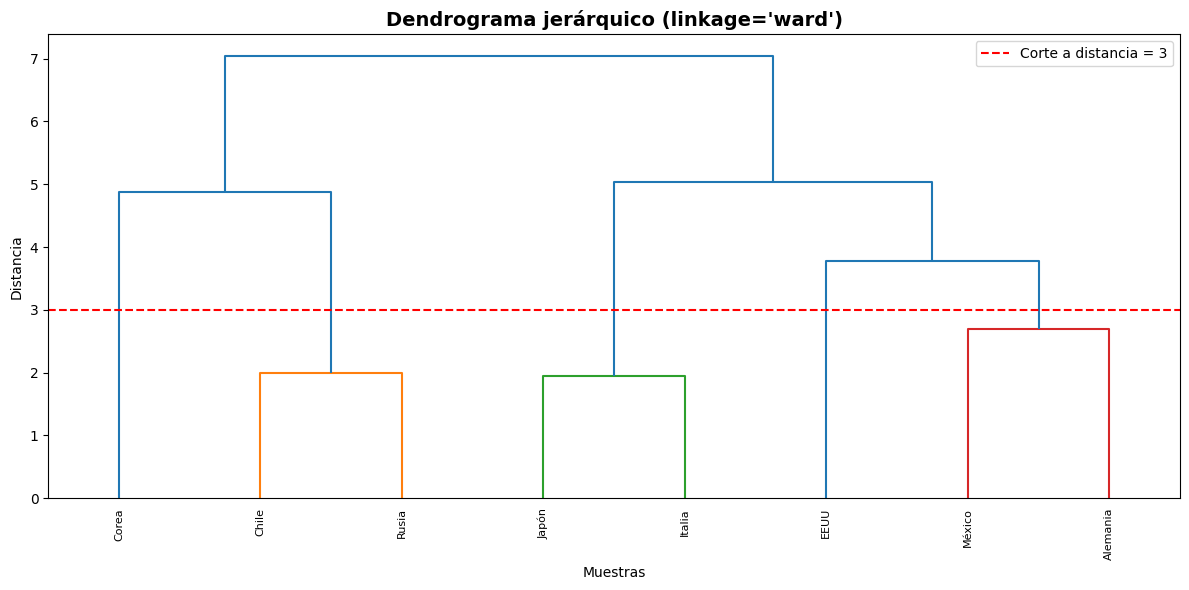

Clusters formados al cortar en 3: 5

 País perteneciente al cluster
-------------------------------
╒══════════╤═══════════╕
│ País     │   cluster │
╞══════════╪═══════════╡
│ Chile    │         1 │
├──────────┼───────────┤
│ EEUU     │         5 │
├──────────┼───────────┤
│ México   │         4 │
├──────────┼───────────┤
│ Corea    │         2 │
├──────────┼───────────┤
│ Japón    │         3 │
├──────────┼───────────┤
│ Alemania │         4 │
├──────────┼───────────┤
│ Rusia    │         1 │
├──────────┼───────────┤
│ Italia   │         3 │
╘══════════╧═══════════╛


In [227]:
# Dendograma con distancia 3.0
Z, labels, ncl = plot_dendrogram_with_cut(
    df=df,
    method="ward",
    metric="euclidean",
    scale=True,
    scaler="standard",
    cut_height=3,     # AJUSTA este valor según tu escala/distancias
    figsize=(12, 6)
)
tabla(labels, title="País perteneciente al cluster")


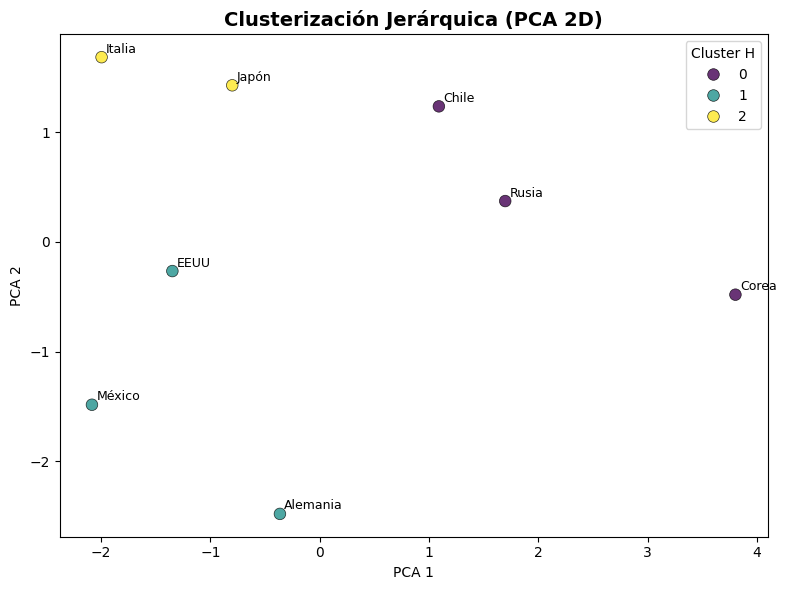

In [228]:
# Clustering jerárquico

X = res_cinco['df_pca'][['PC1', 'PC2']]   # aseguramos solo PCA
hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
y_hc = hc.fit_predict(X)

# Guardar etiquetas en el DF PCA
df_plot = res_cinco['df_pca'].copy()
df_plot["cluster_h"] = y_hc

# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x="PC1", y="PC2",
    hue="cluster_h",
    palette="viridis",
    s=70, alpha=0.8,
    edgecolor="k", linewidth=0.5
)
# Etiquetas con el índice (p.ej., países)
for idx, (x, y) in df_plot[["PC1", "PC2"]].iterrows():
    plt.annotate(str(idx), (x+0.04, y+0.04), fontsize=9)
plt.title("Clusterización Jerárquica (PCA 2D)", fontsize=14, weight="bold")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster H")
plt.tight_layout()
plt.show()

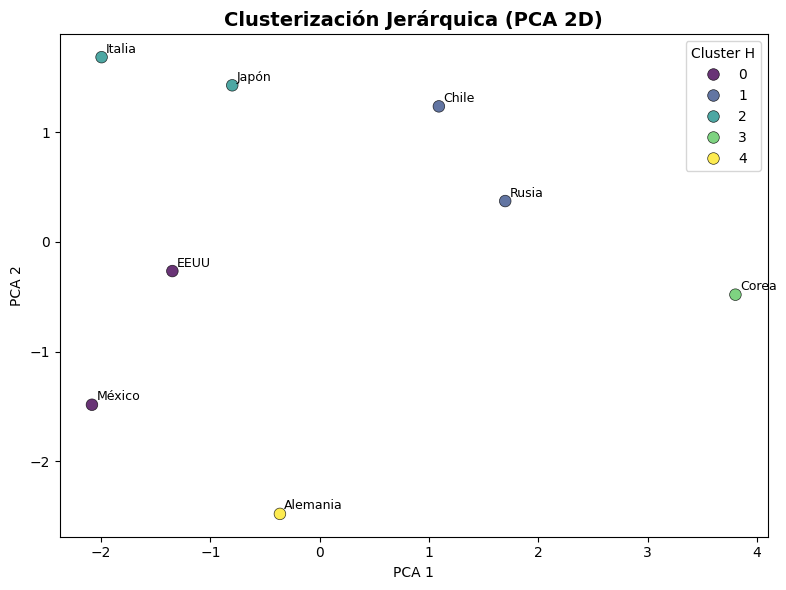

In [229]:
# Clustering jerárquico

X = res_cinco['df_pca'][['PC1', 'PC2']]   # aseguramos solo PCA
hc = AgglomerativeClustering(n_clusters=5, linkage="ward")
y_hc = hc.fit_predict(X)

# Guardar etiquetas en el DF PCA
df_plot = res_cinco['df_pca'].copy()
df_plot["cluster_h"] = y_hc

# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x="PC1", y="PC2",
    hue="cluster_h",
    palette="viridis",
    s=70, alpha=0.8,
    edgecolor="k", linewidth=0.5
)
# Etiquetas con el índice (p.ej., países)
for idx, (x, y) in df_plot[["PC1", "PC2"]].iterrows():
    plt.annotate(str(idx), (x+0.04, y+0.04), fontsize=9)
plt.title("Clusterización Jerárquica (PCA 2D)", fontsize=14, weight="bold")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster H")
plt.tight_layout()
plt.show()

### Comparación clúster vs k means

Al momento de tenerla misma cantidad de clústers, no hay diferencia en la división de los datos, por ende podría decirse que son iguales.  cabe destacar que la dimensionalidad es muy baja como para sacar conclusiones. se recomienda agrandar la mustra.

**DBSCAN**  
- Aplica **DBSCAN** con distintos `eps` y `MinPts`.  
- Justifica parámetros y analiza si DBSCAN **identifica agrupaciones significativas**.


In [230]:
# Funcion dbscan

def run_dbscan(
    df,
    eps=None,                # si None, se estima automáticamente
    min_samples=4,
    distance=None,           # si None, usa min_samples
    scale=True,
    scaler="standard",       # "standard" | "minmax"
    palette="viridis",
    random_state=42,
    show_plot=True,
    auto_sweep=True          # probar eps alrededor de la sugerencia
):
    """
    DBSCAN con estimación automática de eps usando k-distance plot.
    Devuelve dict con modelo, labels_df, df_pca, cluster_counts y eps_usado.
    Visualiza clusters en 2D con PCA.
    
    Parámetros
    ----------
    df : DataFrame
        DataFrame con variables numéricas.
    eps : float
        Radio de vecindad (DBSCAN).
    min_samples : int
        Mínimo de puntos vecinos para ser un cluster.
    scale : bool
        Si True, escala los datos antes de DBSCAN.
    scaler : str
        Método de escalado: "standard" o "minmax".
    palette : str o lista
        Paleta de colores para graficar clusters.
    random_state : int
        Semilla para PCA (solo visualización).
    show_plot : bool
        Si True, dibuja gráfico PCA 2D con clusters.
    
    Retorna
    -------
    dict con:
      - model : objeto DBSCAN
      - labels_df : DataFrame con etiquetas de cluster
      - df_pca : DataFrame con PC1, PC2 y cluster
      - cluster_counts : tabla con conteo por cluster
    """
    # 1) Extraer numéricas

    df_num = df.select_dtypes(include=[np.number]).copy()
    df_num = df_num.replace([np.inf, -np.inf], np.nan).dropna()
    
    if df_num.empty:
        raise ValueError("El DataFrame no contiene columnas numéricas válidas.")

    # 2) Escalado opcional

    X = df_num.values
    scaler_obj = None
    if scale:
        if scaler == "standard":
            scaler_obj = StandardScaler()
        elif scaler == "minmax":
            scaler_obj = MinMaxScaler()
        else:
            raise ValueError("scaler debe ser 'standard' o 'minmax'.")
        X_used = scaler_obj.fit_transform(X)
    else:
        X_used = X

    # 3) k-distance plot para sugerir eps 
    
    k = int(distance) if distance is not None else int(min_samples)
    k = max(2, k)  # al menos 2 vecinos
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_used)
    distances, _ = nbrs.kneighbors(X_used)
    kdist = np.sort(distances[:, -1])

    if show_plot:
            plt.figure(figsize=(7,4))
            plt.plot(kdist, color=VIRIDIS[9])
            plt.title(f"k-distance plot (k={k})", 
                      fontsize=12, 
                      weight="bold")
            plt.xlabel("Puntos ordenados")
            plt.ylabel("Distancia al k-ésimo vecino")
            plt.tight_layout()
            plt.show()

    # Heurística: percentil 90 como punto inicial para eps
    eps_guess = float(np.percentile(kdist, 90))


    if eps is None:
        eps = eps_guess

    # 4) Barrido opcional alrededor de la sugerencia para evitar “todo ruido” o “mega cluster”
    def eval_dbscan(eps_val):
        labels = DBSCAN(eps=eps_val, min_samples=min_samples).fit_predict(X_used)
        # métricas: num_clusters (excluye ruido), proporción de ruido, silueta (sin ruido)
        mask = labels != -1
        n_clusters = len(np.unique(labels[mask])) if mask.any() else 0
        noise_ratio = 1.0 - (mask.sum() / len(labels))
        sil = np.nan
        if mask.sum() > 1 and n_clusters > 1:
            sil = silhouette_score(X_used[mask], labels[mask])
        return labels, n_clusters, noise_ratio, sil

    if auto_sweep:
        # probar 6 valores alrededor de eps (~±20%)
        candidates = np.linspace(0.8*eps, 1.2*eps, 6)
        best = None
        for c in candidates:
            labels_c, ncl, noise, sil = eval_dbscan(c)
            # criterio: prioriza tener ≥2 clusters, luego menor ruido, luego mayor silueta
            score = (
                (ncl >= 2),
                -noise,                 # menos ruido mejor
                (sil if np.isfinite(sil) else -1)
            )
            if (best is None) or (score > best[0]):
                best = (score, c, labels_c, ncl, noise, sil)
        _, eps, labels, ncl, noise, sil = best
    else:
        labels, ncl, noise, sil = eval_dbscan(eps)

    print(f"Sugerencia inicial eps ≈ {eps_guess:.3f} | Usado eps = {eps:.3f} | clusters={ncl} | ruido={noise:.2%}")
    
    # 5) Resultados como DF
    labels_df = pd.DataFrame({"cluster": labels}, index=df_num.index)

    cluster_counts = (
        labels_df["cluster"].value_counts().sort_index().to_frame("Cantidad de datos")
    )
    cluster_counts["Proporción"] = (cluster_counts["Cantidad de datos"] / len(labels) * 100).round(2)

    # 6) PCA para visualización
    pca = PCA(n_components=2, random_state=random_state)
    X_pca = pca.fit_transform(X_used)
    df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=df_num.index)
    df_pca["cluster"] = labels

    # 7) Plot
    if show_plot:
        uniq = sorted([c for c in np.unique(labels) if c != -1])
        pal = sns.color_palette("viridis", n_colors=len(uniq)) if palette == "viridis" else palette
        pal_map = {cl: pal[i] for i, cl in enumerate(uniq)}
        pal_map[-1] = (0.6, 0.6, 0.6)  # ruido en gris

        plt.figure(figsize=(8,6))
        sns.scatterplot(
            data=df_pca, x="PC1", y="PC2",
            hue="cluster",
            palette=pal_map,
            alpha=0.85, s=70, edgecolor="k", linewidth=0.5
        )
        t = f"DBSCAN (eps={eps:.3f}, min_samples={min_samples}, scale={scale})"
        if np.isfinite(sil):
            t += f" | Sil (sin ruido)={sil:.3f}"
            # Etiquetas con el índice (p.ej., países)
        for idx, (x, y) in df_pca[["PC1", "PC2"]].iterrows():
            plt.annotate(str(idx), (x+0.04, y+0.04), fontsize=9)
        plt.title(t, fontsize=14, weight="bold")
        plt.xlabel("PC1"); plt.ylabel("PC2")
        plt.legend(title="Cluster (−1=ruido)")
        plt.tight_layout()
        plt.show()

    return {
        "model": DBSCAN(eps=eps, min_samples=min_samples).fit(X_used),
        "eps_used": eps,
        "labels_df": labels_df,
        "df_pca": df_pca,
        "cluster_counts": cluster_counts
    }           

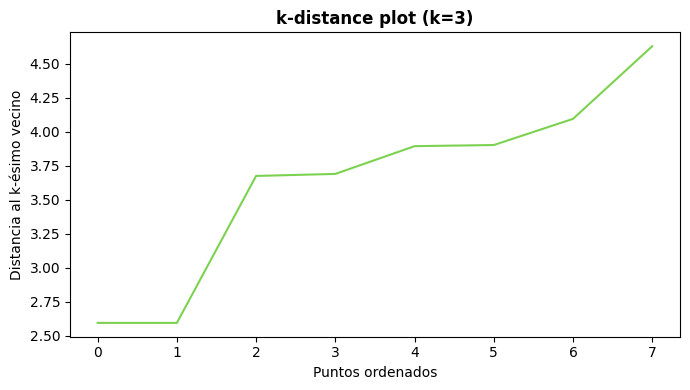

Sugerencia inicial eps ≈ 4.255 | Usado eps = 4.255 | clusters=1 | ruido=0.00%


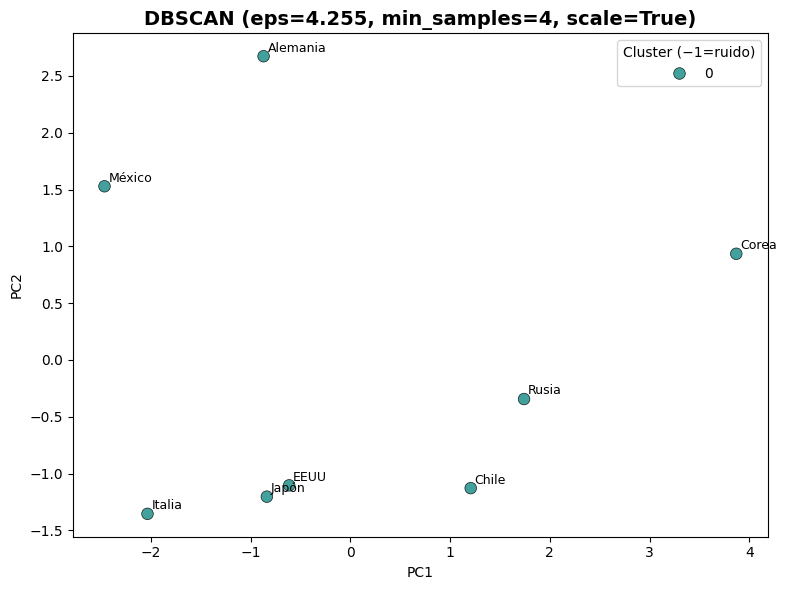

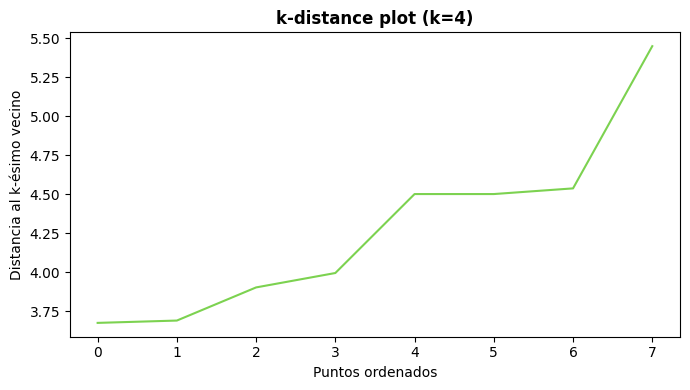

Sugerencia inicial eps ≈ 4.810 | Usado eps = 5.000 | clusters=1 | ruido=0.00%


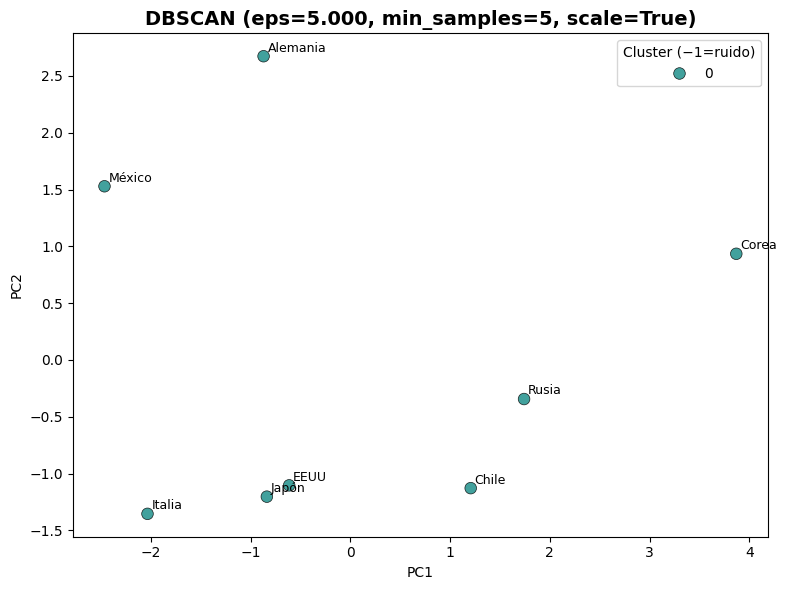

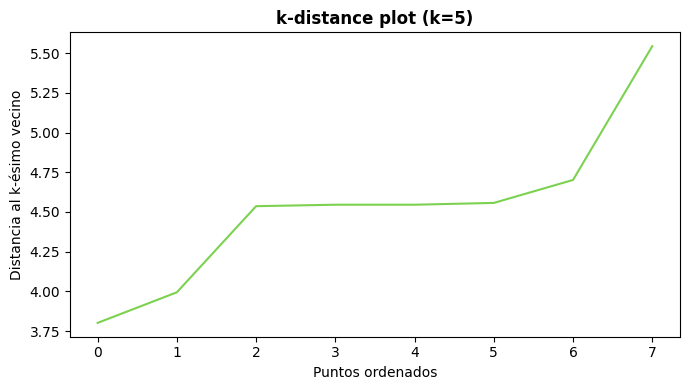

Sugerencia inicial eps ≈ 4.954 | Usado eps = 6.000 | clusters=1 | ruido=0.00%


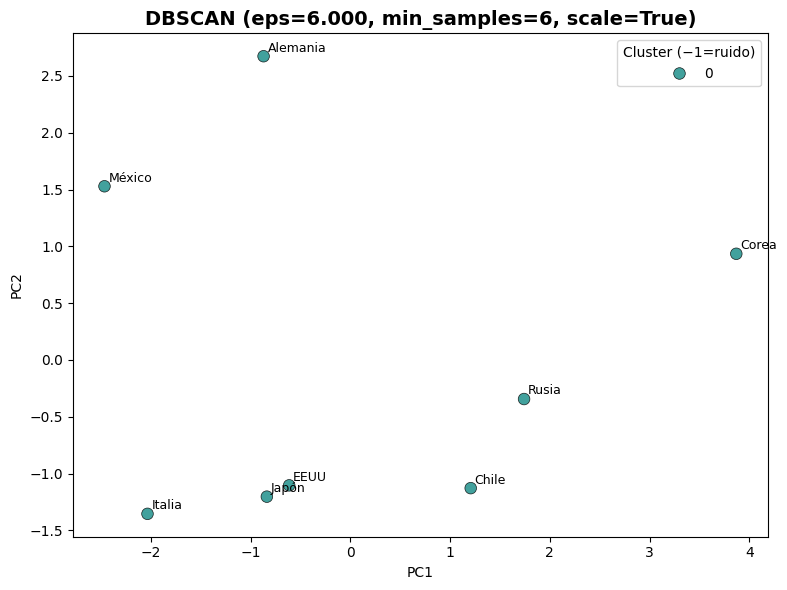

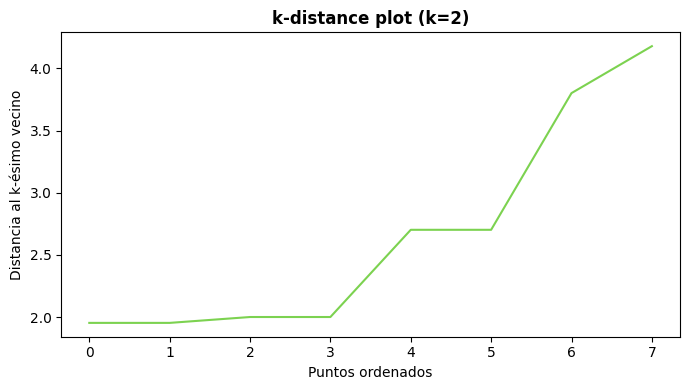

Sugerencia inicial eps ≈ 3.915 | Usado eps = 3.132 | clusters=2 | ruido=25.00%


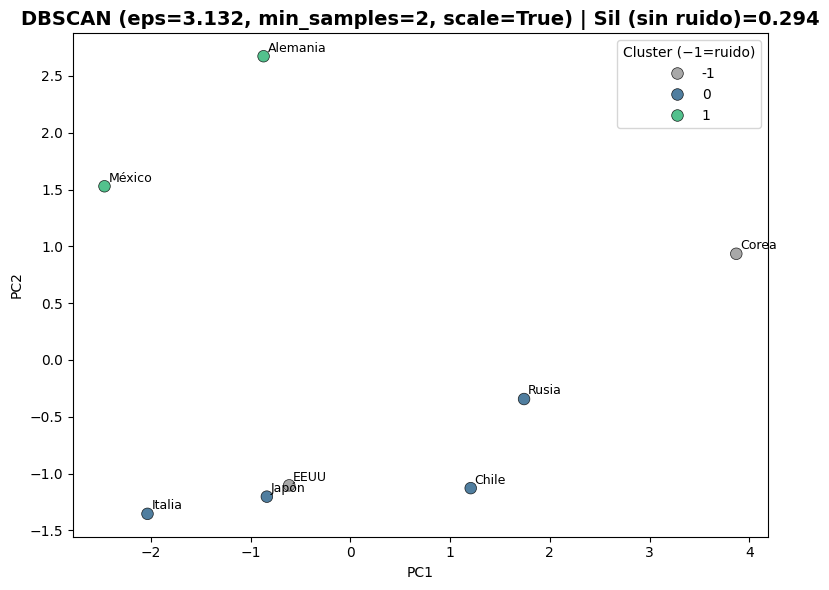

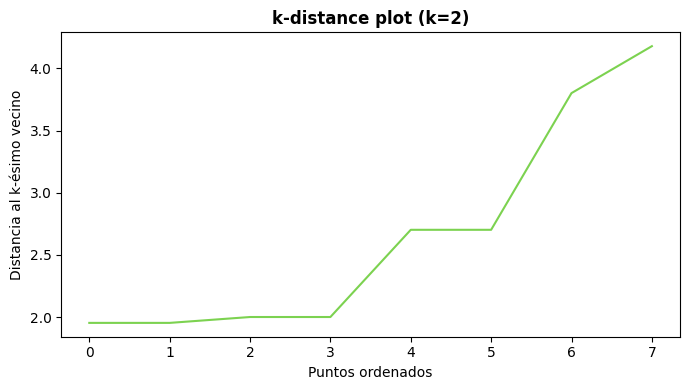

Sugerencia inicial eps ≈ 3.915 | Usado eps = 4.071 | clusters=2 | ruido=0.00%


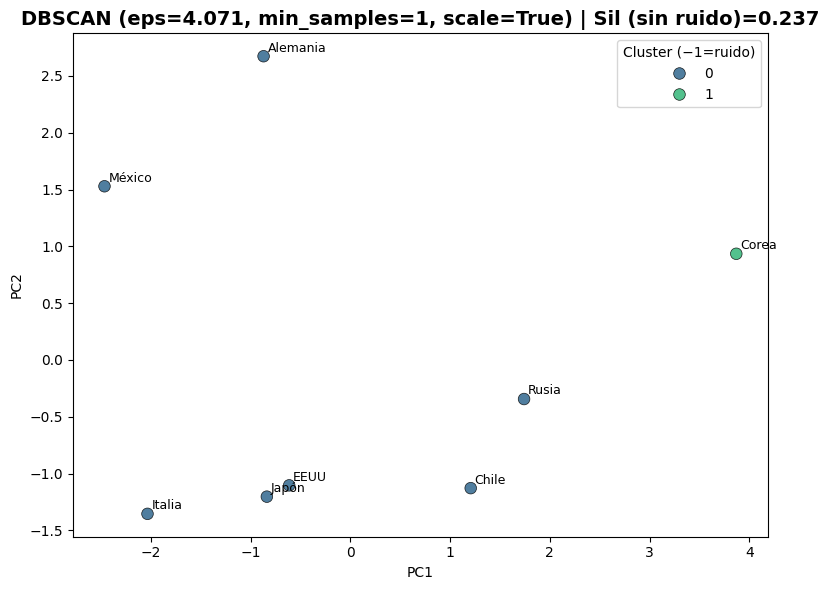

In [231]:
# DBSCAn eps auto, minpts =4, dist=3
res_db_uno = run_dbscan(
    df=res_cinco["df_with_clusters"],  # o el DF numérico que uses
    eps=None,             # que estime solo
    min_samples=4,
    scale=True,
    scaler="standard",
    auto_sweep=False,      # que pruebe alrededor del eps sugerido
    show_plot=True, 
    distance=3
)

# DBSCAn eps=5 , minpts =5, dist=4
res_db_dos = run_dbscan(
    df=res_cinco["df_with_clusters"],  # o el DF numérico que uses
    eps=5,             
    min_samples=5,
    scale=True,
    scaler="standard",
    auto_sweep=False,      
    show_plot=True, 
    distance=4
)

# DBSCAn eps=6, minpts =6, dist=5
res_db_dos = run_dbscan(
    df=res_cinco["df_with_clusters"],  # o el DF numérico que uses
    eps=6,             
    min_samples=6,
    scale=True,
    scaler="standard",
    auto_sweep=False,      
    show_plot=True, 
    distance=5
)
# DBSCAn eps=6, minpts =6, dist=5
res_db_dos = run_dbscan(
    df=res_cinco["df_with_clusters"],  # o el DF numérico que uses
    eps=None,             
    min_samples=2,
    scale=True,
    scaler="standard",
    auto_sweep=True,      
    show_plot=True, 

)
# DBSCAn eps=6, minpts =6, dist=5
res_db_dos = run_dbscan(
    df=res_cinco["df_with_clusters"],  # o el DF numérico que uses
    eps=None,             
    min_samples=1,
    scale=True,
    scaler="standard",
    auto_sweep=True,      
    show_plot=True, 

)

Se modifican todos los parámetros, y se ve diferencia al momento de modificar la variable min samples, en dnd podemos obtener 2 clústers, y dos valores como ruído 

## 3. Reducción de dimensionalidad (3 puntos)
**PCA**  
- Determina cuántos componentes explican **≥ 90%** de la varianza.  
- Visualiza países en 2D con las **dos primeras componentes**.


In [232]:
# Función PCA

def run_pca_analysis(df):
    """
    Recibe un DataFrame (df), toma solo columnas numéricas,
    estandariza, calcula PCA y:
      1) Determina # de componentes para ≥90% varianza (lo imprime).
      2) Dibuja scree plot acumulado con líneas guía al 90%.
      3) Grafica países en 2D (PC1 vs PC2) con etiquetas (índice como país).

    Retorna:
      dict con:
        - n_components_90
        - explained_variance_ratio_
        - cumulative_variance
        - pca_2d_df (DataFrame con PC1, PC2)
        - pca (objeto PCA ajustado sobre datos estandarizados)
        - scaler (StandardScaler ajustado)
    """
    # 1) Numéricas limpias
    df_num = df.select_dtypes(include=[np.number]).copy()
    df_num = df_num.replace([np.inf, -np.inf], np.nan).dropna()
    if df_num.empty:
        raise ValueError("El DataFrame no contiene columnas numéricas válidas.")
    
    # 2) Escalado
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_num)

    # 3) PCA con todas las componentes
    pca_full = PCA().fit(X_scaled)
    explained = pca_full.explained_variance_ratio_
    cum_explained = np.cumsum(explained)

    # 4) # comp ≥ 90%
    n_components_90 = int(np.argmax(cum_explained >= 0.90) + 1)
    print(f"Número de componentes que explican ≥90% de la varianza: {n_components_90}")

    # 5) Scree plot acumulado
    plt.figure(figsize=(8,5))
    xs = np.arange(1, len(explained) + 1)
    plt.plot(xs, cum_explained, marker="o", color=VIRIDIS[7])
    plt.axhline(0.90, linestyle="--", color="red", label="90% varianza")
    plt.axvline(n_components_90, linestyle="--", color=VIRIDIS[4], label=f"{n_components_90} componentes")
    plt.title("Varianza acumulada por componentes principales", fontsize=14, weight="bold")
    plt.xlabel("Número de componentes")
    plt.ylabel("Varianza acumulada")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 6) Proyección 2D (PC1 y PC2)
    pca_2d = PCA(n_components=2, random_state=42)
    X_2d = pca_2d.fit_transform(X_scaled)
    pca_2d_df = pd.DataFrame(X_2d, columns=["PC1", "PC2"], index=df_num.index)

    plt.figure(figsize=(8,6))
    plt.scatter(pca_2d_df["PC1"], pca_2d_df["PC2"], s=80,
                 alpha=0.75,
                color=VIRIDIS[9],
                edgecolor="k")
    # Etiquetas con el índice (p.ej., países)
    for idx, (x, y) in pca_2d_df[["PC1", "PC2"]].iterrows():
        plt.annotate(str(idx), (x+0.05, y+0.05), fontsize=9)
    plt.title("Países proyectados en 2D (PC1 vs PC2)", fontsize=14, weight="bold")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    return {
        "n_components_90": n_components_90,
        "explained_variance_ratio_": explained,
        "cumulative_variance": cum_explained,
        "pca_2d_df": pca_2d_df,
        "pca": pca_full,
        "scaler": scaler,
    }


Número de componentes que explican ≥90% de la varianza: 4


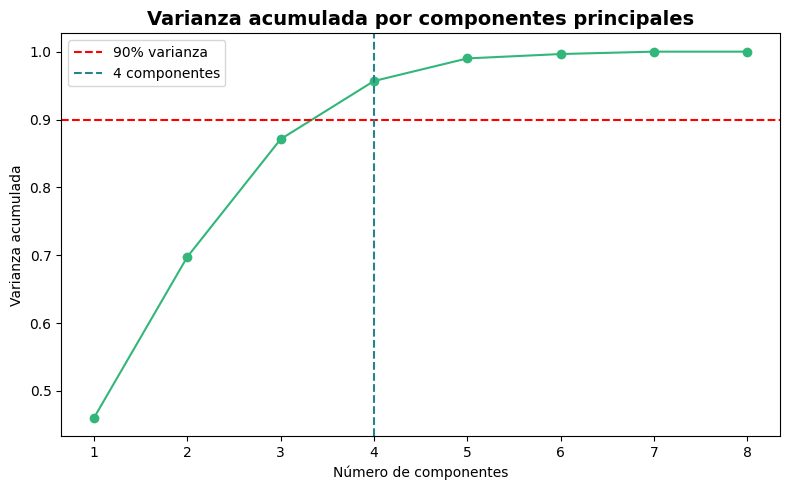

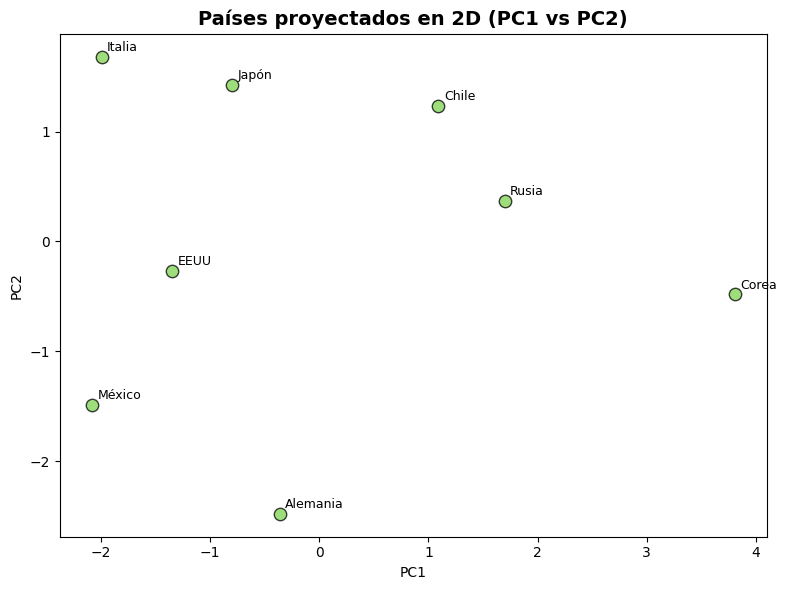

(4,
              PC1       PC2
 País                      
 Chile   1.090496  1.234167
 EEUU   -1.348107 -0.266883
 México -2.083906 -1.485118
 Corea   3.803908 -0.482096
 Japón  -0.800312  1.426099)

In [233]:
# Aplicación de PCA

res_pca = run_pca_analysis(df)
res_pca["n_components_90"], res_pca["pca_2d_df"].head()


**t-SNE**  
- Visualiza en 2D.  
- Prueba distintos valores de **perplexity** y comenta su impacto.


In [234]:
# Función t_SNE

def plot_tsne(
    df,
    cluster_col="cluster",        # nombre de la columna con tus etiquetas previas
    features=None,                # lista de columnas numéricas a usar; si None, toma todas (menos cluster)
    scale=True,                   # escalar antes de t-SNE
    scaler="standard",            # "standard" | "minmax"
    perplexity=30,                # se ajusta automáticamente si es demasiado grande para n
    random_state=42,
    annotate_points=True,
    palette="viridis",
    point_size=70
):
    """
    Aplica t-SNE a df usando variables numéricas y colorea por el cluster ya existente.
    Devuelve df_tsne (Componente t-SNE 1/2 + cluster).
    """
    if cluster_col not in df.columns:
        raise ValueError(f"No se encontró la columna de cluster '{cluster_col}' en df.")

    # 1) Selección de features numéricas
    if features is None:
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if cluster_col in num_cols:
            num_cols.remove(cluster_col)
    else:
        num_cols = list(features)

    if len(num_cols) == 0:
        raise ValueError("No hay columnas numéricas (features) para t-SNE.")
    
    df_num = df[num_cols].copy()
    # Limpieza básica
    df_num = df_num.replace([np.inf, -np.inf], np.nan).dropna()
    # Alinear etiquetas y mantener índice
    y = df.loc[df_num.index, cluster_col]

    n = df_num.shape[0]
    if n < 3:
        raise ValueError("Se requieren ≥3 filas para t-SNE.")

    # 2) Escalado opcional
    X = df_num.values
    if scale:
        if scaler == "standard":
            X = StandardScaler().fit_transform(X)
        elif scaler == "minmax":
            X = MinMaxScaler().fit_transform(X)
        else:
            raise ValueError("scaler debe ser 'standard' o 'minmax'.")

    # 3) Validar/ajustar perplexity
    # Regla práctica: perplexity < n y típicamente entre 5 y 50
    if perplexity >= n:
        perplexity = max(5, min(50, n // 3))

    # 4) t-SNE (parámetros estables)
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
        learning_rate="auto"
    )
    X_tsne = tsne.fit_transform(X)

    # 5) DataFrame de salida con clusters
    df_tsne = pd.DataFrame(
        X_tsne, columns=["Componente t-SNE 1", "Componente t-SNE 2"], index=df_num.index
    )
    df_tsne[cluster_col] = y.values

    # 6) Plot
    plt.figure(figsize=(8, 6))
    levels = sorted(pd.unique(df_tsne[cluster_col].dropna()))
    pal = sns.color_palette("viridis", n_colors=len(levels)) if palette == "viridis" else palette
    ax = sns.scatterplot(
        data=df_tsne,
        x="Componente t-SNE 1", y="Componente t-SNE 2",
        hue=cluster_col, hue_order=levels, palette=pal,
        s=point_size, alpha=0.85, edgecolor="k", linewidth=0.5
    )

    # Anotaciones con el índice
    if annotate_points:
        x_range = df_tsne["Componente t-SNE 1"].max() - df_tsne["Componente t-SNE 1"].min()
        y_range = df_tsne["Componente t-SNE 2"].max() - df_tsne["Componente t-SNE 2"].min()
        dx = 0.01 * x_range if x_range > 0 else 0.03
        dy = 0.01 * y_range if y_range > 0 else 0.03
        for idx, (xv, yv) in df_tsne[["Componente t-SNE 1", "Componente t-SNE 2"]].iterrows():
            ax.annotate(str(idx), (xv + dx, yv + dy), fontsize=9)

    plt.title(f"t-SNE coloreado por '{cluster_col}' (perplexity={perplexity}, scale={scale})",
              fontsize=14, weight="bold")
    plt.xlabel("Componente t-SNE 1")
    plt.ylabel("Componente t-SNE 2")
    plt.legend(title=cluster_col)
    plt.tight_layout()
    plt.show()

    return df_tsne


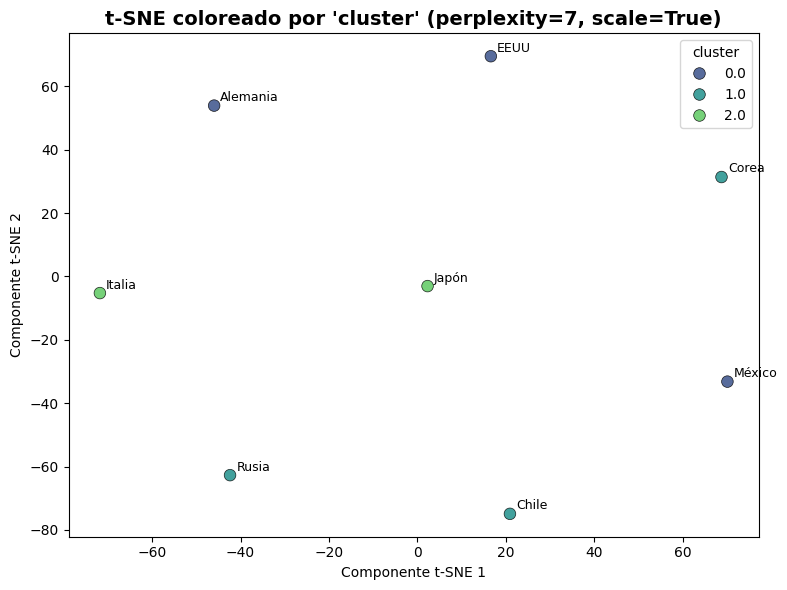

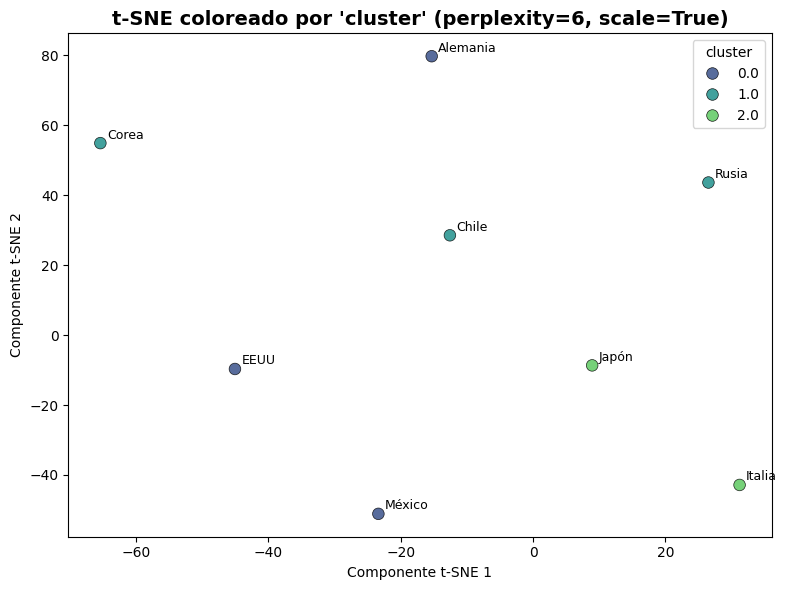

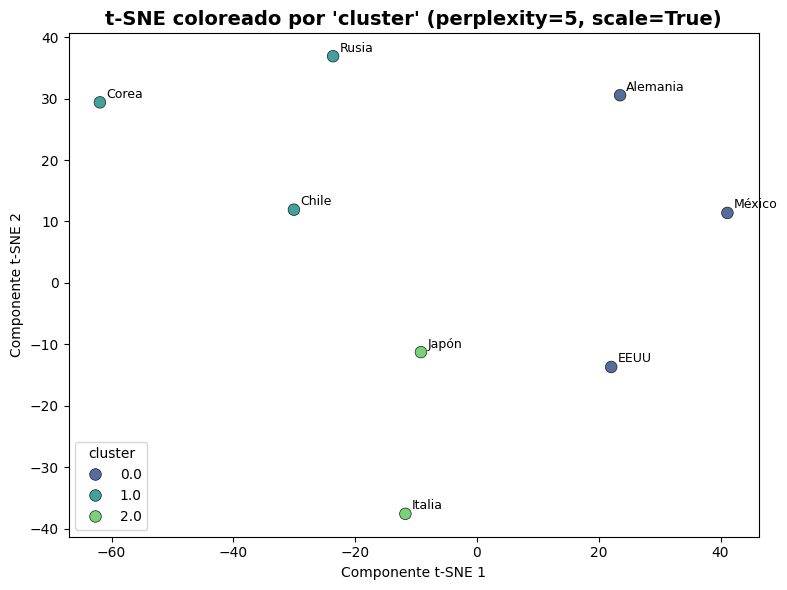

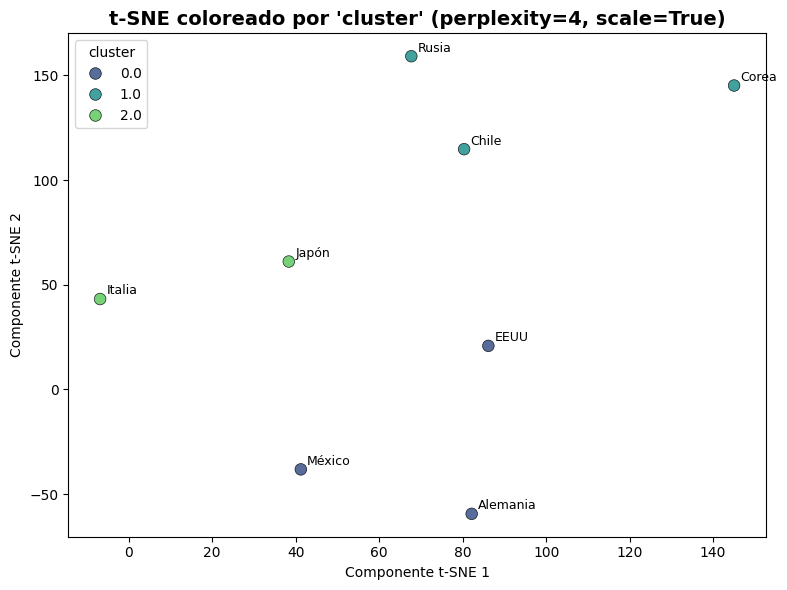

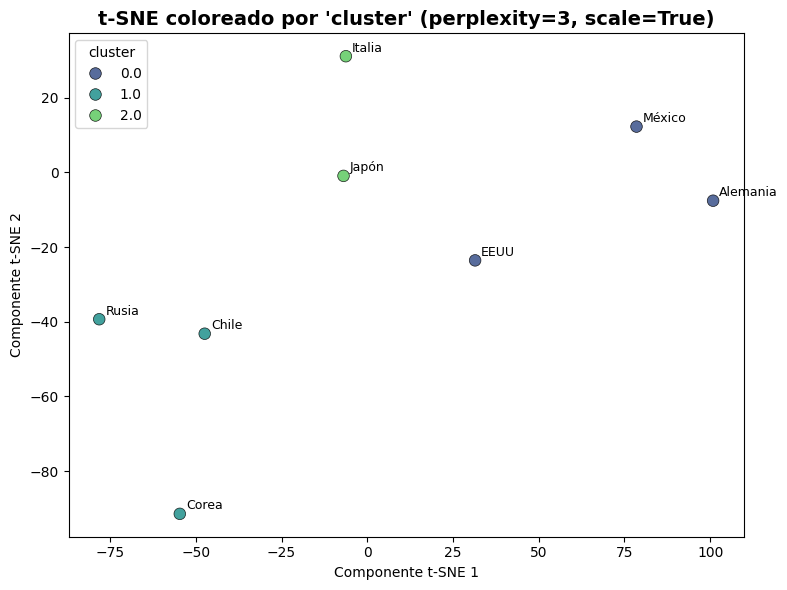

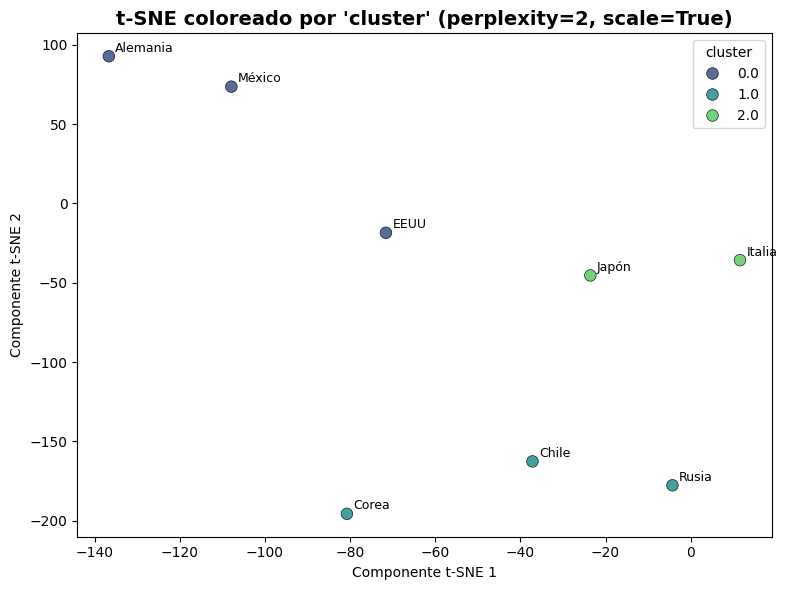

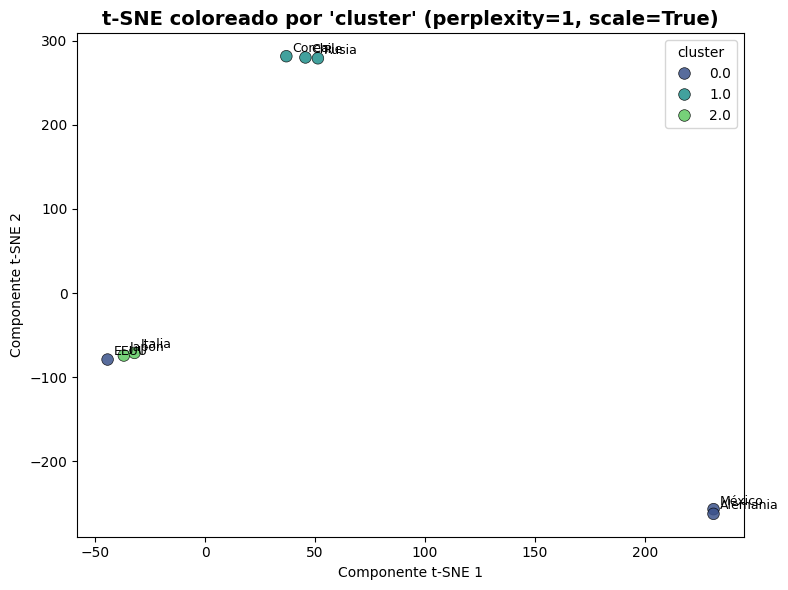

In [235]:
# TSNE Aplicado

# TSNE Perplexity=7
df_tsne = plot_tsne(
    df=res["df_with_clusters"],   # df con la col "cluster"
    cluster_col="cluster",
    scale=True, scaler="standard",
    perplexity=7, random_state=42,
    annotate_points=True,
    palette="viridis"
)
# TSNE Perplexity=6
df_tsne = plot_tsne(
    df=res["df_with_clusters"],   # df con la col "cluster"
    cluster_col="cluster",
    scale=True, scaler="standard",
    perplexity=6, random_state=42,
    annotate_points=True,
    palette="viridis"
)

# TSNE Perplexity=5
df_tsne = plot_tsne(
    df=res["df_with_clusters"],   # df con la col "cluster"
    cluster_col="cluster",
    scale=True, scaler="standard",
    perplexity=5, random_state=42,
    annotate_points=True,
    palette="viridis"
)
# TSNE Perplexity=4
df_tsne = plot_tsne(
    df=res["df_with_clusters"],   # df con la col "cluster"
    cluster_col="cluster",
    scale=True, scaler="standard",
    perplexity=4, random_state=42,
    annotate_points=True,
    palette="viridis"
)
# TSNE Perplexity=3
df_tsne = plot_tsne(
    df=res["df_with_clusters"],   # df con la col "cluster"
    cluster_col="cluster",
    scale=True, scaler="standard",
    perplexity=3, random_state=42,
    annotate_points=True,
    palette="viridis"
)
# TSNE Perplexity=2
df_tsne = plot_tsne(
    df=res["df_with_clusters"],   # df con la col "cluster"
    cluster_col="cluster",
    scale=True, scaler="standard",
    perplexity=2, random_state=42,
    annotate_points=True,
    palette="viridis"
)
# TSNE Perplexity=1
df_tsne = plot_tsne(
    df=res["df_with_clusters"],   # df con la col "cluster"
    cluster_col="cluster",
    scale=True, scaler="standard",
    perplexity=1, random_state=42,
    annotate_points=True,
    palette="viridis"
)

Aplicando diferentes valores de perplexity, se reordenan los puntos.
A medida que los el perxplexity va disminuyendo, los clústeres se van agrupando.
Cuando perplexity = 1 los clústeres están completamente agrupados.

## 4. Resultados y conclusiones (1 punto)\,
**Comparación de métodos**  \,
- Diferencias entre **K-Means, jerárquico y DBSCAN**. ¿Cuál funcionó mejor y por qué? 
- Compara **PCA** vs **t-SNE** para visualizar relaciones entre países.


Funcionó mejor el kmeans y el jerárquico, eso si hay que tener mucho cuidado en el método jerárquico, a que distancia hay que hacer el corte, ya que puede cambiar demasiado solamente cambiando una unidad.
A mi percepción el k means y db scan son los mejores métodos, debido a la facilidad de implementar cuantos clústers se dividirá, ademas que ambos métodos generan centroides bien definidos, para que visualmente se utilice como referencia .

El punto a favor de el método t-SNE es la agrupación con el decreccimiento del perplexity, por ende sería un aporte visual , sin embargo es mas utilizado el método de PCA, y tiene mayor versatilidad. aunque en ambos puntos es mucho más dificil visualizar si se genera más de 2 o 3 componentes.


**Interpretación** 
- ¿Los clusters reflejan **similitudes culturales o geográficas**?
- Relación con **tendencias globales** de consumo musical.

- Los cluster no demuestran similitud cultural ni geográficas, ya que, podemos decir que Rusia y Chile no comparten muchas características en lo cultural, y menos en lo geográfico. Mismo caso pasa entre Alemania y EUA.
- Analizando el pairplot, y asumiendo que los demás países se comportand de manera similar a los ya estudiados, podemos inferir dos cosas. Primero hay una alta población que escucha música clásica, y el género del hip hop, es mucho más escuchado/querido, en el clúster de Chile, Rusia Korea, que en el resto del mundo, y en el clúster de EUA, solamente ellos lo escuchan. Pudiendo ser este un criterio de agrupación.


## INSTRUCCIONES ADICIONALES
- **Puntos totales = 10**.  
- Descarga el material complementario de la plataforma.  
- Comprime en `.zip` o `.rar`.  
- Incluye un documento con **reflexiones analíticas**.  
- Sube el archivo a la plataforma.
